<center> <img src=https://www.kaggle.com/competitions/6960/images/header align="right" width="300"/> </center>

## 1. Постановка задачи

  Вам предстоит решить настоящую задачу машинного обучения, направленную на автоматизацию бизнес процессов. Мы построим модель, которая будет предсказывать общую продолжительность поездки такси в Нью-Йорке. 

Представьте вы заказываете такси из одной точки Нью-Йорка в другую, причем не обязательно конечная точка должна находиться в пределах города. Сколько вы должны будете за нее заплатить? Известно, что стоимость такси в США  рассчитывается на основе фиксированной ставки + тарифная стоимость, величина которой зависит от времени и расстояния. Тарифы варьируются в зависимости от города.

В свою очередь время поездки зависит от множества факторов таких как, откуда и куда вы едете, в какое время суток вы совершаете вашу поездку, погодных условий и так далее. 

Таким образом, если мы разработаем алгоритм, способный определять длительность поездки, мы сможем прогнозировать ее стоимость самым тривиальным образом, например, просто умножая стоимость на заданный тариф. 
Сервисы такси хранят огромные объёмы информации о поездках, включая такие данные как конечная, начальная точка маршрута, дата поездки и ее длительность. Эти данные можно использовать для того, чтобы прогнозировать длительность поездки в автоматическом режиме с привлечением искусственного интеллекта.

**Бизнес-задача:** определить характеристики и с их помощью спрогнозировать длительность поездки такси.

**Техническая задача для вас как для специалиста в Data Science:** построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать числовой признак - время поездки такси. То есть решить задачу регрессии.

**Основные цели проекта:**
1. Сформировать набор данных на основе нескольких источников информации
2. Спроектировать новые признаки с помощью Feature Engineering и выявить наиболее значимые при построении модели
3. Исследовать предоставленные данные и выявить закономерности
4. Построить несколько моделей и выбрать из них наилучшую по заданной метрике
5. Спроектировать процесс предсказания времени длительности поездки для новых данных

Загрузить свое решение на платформу Kaggle, тем самым поучаствовав в настоящем Data Science соревновании.
Во время выполнения проекта вы отработаете навыки работы с несколькими источниками данных, генерации признаков, разведывательного анализа и визуализации данных, отбора признаков и, конечно же, построения моделей машинного обучения!


## 2. Знакомство с данными, базовый анализ и расширение данных

Начнём наше исследование со знакомства с предоставленными данными. А также подгрузим дополнительные источники данных и расширим наш исходный датасет. 


Заранее импортируем модули, которые нам понадобятся для решения задачи:

In [593]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection

Прочитаем наш файл с исходными данными:

In [594]:
taxi_data = pd.read_csv("data/train.csv")
print('Train data shape: {}'.format(taxi_data.shape))
taxi_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Итак, у нас с вами есть данные о почти 1.5 миллионах поездок и 11 характеристиках, которые описывают каждую из поездок. 

Мы условно разделили признаки нескольких групп. Каждой из групп мы в дальнейшем уделим отдельное внимание.

**Данные о клиенте и таксопарке:**
* id - уникальный идентификатор поездки
* vendor_id - уникальный идентификатор поставщика (таксопарка), связанного с записью поездки

**Временные характеристики:**
* pickup_datetime - дата и время, когда был включен счетчик поездки
* dropoff_datetime - дата и время, когда счетчик был отключен

**Географическая информация:**
* pickup_longitude -  долгота, на которой был включен счетчик
* pickup_latitude - широта, на которой был включен счетчик
* dropoff_longitude - долгота, на которой счетчик был отключен
* dropoff_latitude - широта, на которой счетчик был отключен

**Прочие признаки:**
* passenger_count - количество пассажиров в транспортном средстве (введенное водителем значение)
* store_and_fwd_flag - флаг, который указывает, сохранилась ли запись о поездке в памяти транспортного средства перед отправкой поставщику. Y - хранить и пересылать, N - не хранить и не пересылать поездку.

**Целевой признак:**
* trip_duration - продолжительность поездки в секундах


Для начала мы проведем базовый анализ того, насколько данные готовы к дальнейшей предобработке и анализу. 

### Задание 2.1
Для начала посмотрим на временные рамки, в которых мы работаем с данными.

Переведите признак pickup_datetime в тип данных datetime с форматом год-месяц-день час:минута:секунда (в функции pd.to_datetime() параметр format='%Y-%m-%d %H:%M:%S'). 

Определите временные рамки (без учета времени), за которые представлены данные.

In [595]:
# ваш код здесь
taxi_data['pickup_datetime']=pd.to_datetime(taxi_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')
print(f"Временные рамки от {taxi_data['pickup_datetime'].dt.date.min()} до {taxi_data['pickup_datetime'].dt.date.max()}")

Временные рамки от 2016-01-01 до 2016-06-30


### Задание 2.2
Посмотрим на пропуски. 
Сколько пропущенных значений присутствует в данных (суммарно по всем столбцам таблицы)?

In [596]:
# ваш код здесь
cols_null_percent = taxi_data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
if cols_with_null.empty:
    print("Пропусков в датасете нет.")
else:
    print("Столбцы с пропусками (в процентах):")
    print(cols_with_null)

Пропусков в датасете нет.


### Задание 2.3
Посмотрим на статистические характеристики некоторых признаков. 

а) Сколько уникальных таксопарков присутствует в данных?

б) Каково максимальное количество пассажиров?

в) Чему равна средняя и медианная длительность поездки? Ответ приведите в секундах и округлите до целого.

г) Чему равно минимальное и максимальное время поездки (в секундах)?


In [597]:
# ваш код здесь
print(f"В данных присутствуют данные о {taxi_data['vendor_id'].nunique()} уникальных таксопарков\n")
print(f"Максимальное количество пассажиров в поездке - {taxi_data['passenger_count'].max()}\n")

taxi_data['dropoff_datetime']=pd.to_datetime(taxi_data['dropoff_datetime'],format='%Y-%m-%d %H:%M:%S')
trip_duration_seconds = (taxi_data['dropoff_datetime'] - taxi_data['pickup_datetime']).dt.total_seconds()

print(f"Средняя длительность поездки составляет - {round(trip_duration_seconds.mean())} секунд")
print(f"Медианная длительность поездки составляет - {round(trip_duration_seconds.median())} секунд\n")
print(f"Минимальное время поездки составляет - {round(trip_duration_seconds.min())} секунд")
print(f"Максимальное время поездки составляет - {round(trip_duration_seconds.max())} секунд")

В данных присутствуют данные о 2 уникальных таксопарков

Максимальное количество пассажиров в поездке - 9

Средняя длительность поездки составляет - 959 секунд
Медианная длительность поездки составляет - 662 секунд

Минимальное время поездки составляет - 1 секунд
Максимальное время поездки составляет - 3526282 секунд


Займемся расширением исходного набора данных как с помощью внешних источников, так и с помощью манипуляций над имеющимися в данных признаками. 


### Задание 2.4
Реализуйте функцию add_datetime_features(), которая принимает на вход таблицу с данными о поездках (DataFrame) и возвращает ту же таблицу с добавленными в нее 3 столбцами:
* pickup_date - дата включения счетчика - начала поездки (без времени);
* pickup_hour - час дня включения счетчика;
* pickup_day_of_week - порядковый номер дня недели (число), в который был включен счетчик.

а) Сколько поездок было совершено в субботу?

б) Сколько поездок в среднем совершается в день? Ответ округлите до целого

In [598]:
# ваш код здесь
def add_datetime_features(df):
    df['pickup_date'] = df['pickup_datetime'].dt.date               # дата без времени
    df['pickup_hour'] = df['pickup_datetime'].dt.hour               # час дня (0–23)
    df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek   # день недели: 0=понедельник, 6=воскресенье
    return df

In [599]:
add_datetime_features(taxi_data)
print(f"В субботу было совершено {taxi_data[taxi_data['pickup_day_of_week']==5]['pickup_day_of_week'].count()} поездок")
avg_rides_per_day = taxi_data.groupby('pickup_date').size().mean()
print(f"В среднем совершается {avg_rides_per_day:.0f} поездок в день")

В субботу было совершено 220868 поездок
В среднем совершается 8015 поездок в день


### Задание 2.5
Реализуйте функцию add_holiday_features(), которая принимает на вход две таблицы: 
* таблицу с данными о поездках;
* таблицу с данными о праздничных днях;

и возвращает обновленную таблицу с данными о поездках с добавленным в нее столбцом pickup_holiday - бинарным признаком того, начата ли поездка в праздничный день или нет (1 - да, 0 - нет). 

Чему равна медианная длительность поездки на такси в праздничные дни? Ответ приведите в секундах, округлив до целого.


In [600]:
holiday_data = pd.read_csv('data/holiday_data.csv', sep=';')
# ваш код здесь
def add_holiday_features(taxi_df: pd.DataFrame, holiday_df: pd.DataFrame) -> pd.DataFrame:
    # Делаем копию, чтобы не менять исходные данные
    df = taxi_df.copy()
    
    # Приводим даты в holiday_df к типу date (без времени)
    holiday_dates = pd.to_datetime(holiday_df['date']).dt.date.unique()
        
    # Добавляем бинарный признак: 1 — если поездка в праздник, 0 — иначе
    df['pickup_holiday'] = df['pickup_date'].isin(holiday_dates).astype(int)
    
    return df

In [601]:
taxi_data = add_holiday_features(taxi_data, holiday_data)
mask1=taxi_data['pickup_holiday']==1
trip_duration_holidays = (taxi_data[mask1]['dropoff_datetime'] - taxi_data[mask1]['pickup_datetime']).dt.total_seconds()
print(f"Медианная длительность поездки на такси в праздничные дни - {round(trip_duration_holidays.median())} секунд")

Медианная длительность поездки на такси в праздничные дни - 585 секунд


### Задание 2.6
Реализуйте функцию add_osrm_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными из OSRM;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 3 столбцами:
* total_distance;
* total_travel_time;
* number_of_steps.

а) Чему равна разница (в секундах) между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM? 

В результате объединения таблиц у вас должны были получиться пропуски в столбцах с информацией из OSRM API. Это связано с тем, что для некоторых поездок не удалось выгрузить данные из веб источника. 

б) Сколько пропусков содержится в столбцах с информацией из OSRM API после объединения таблиц?

In [602]:
osrm_data = pd.read_csv('data/osrm_data_train.csv')

# ваш код здесь
def add_osrm_features(taxi_df: pd.DataFrame, osrm_df: pd.DataFrame) -> pd.DataFrame:
    # Выбираем ключ и 3 нужных столбца из osrm_data
    cols_to_merge = ['id', 'total_distance', 'total_travel_time', 'number_of_steps']
    
    # Left join: сохраняем все строки из taxi_df
    df = pd.merge(
        taxi_df,
        osrm_df[cols_to_merge],
        on='id',
        how='left'
    )
    
    return df

In [603]:
taxi_data = add_osrm_features(taxi_data, osrm_data)
taxi_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_hour,pickup_day_of_week,pickup_holiday,total_distance,total_travel_time,number_of_steps
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,17,0,0,2009.1,164.9,5.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,0,6,0,2513.2,332.0,6.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,11,1,0,11060.8,767.6,16.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,19,2,0,1779.4,235.8,4.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,13,5,0,1614.9,140.1,5.0


In [604]:
time_from_taxi_data=round(trip_duration_seconds.median())
time_from_OSRM=round(taxi_data['total_travel_time'].median())
print(f"Разница между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM составляет \n{time_from_taxi_data-time_from_OSRM} секунд")

Разница между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM составляет 
372 секунд


In [605]:
rows_with_missing = taxi_data.isna().any(axis=1).sum()
print(f"Строк с пропусками: {rows_with_missing}")

Строк с пропусками: 1


In [606]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371 
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def get_angle_direction(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

### Задание 2.7.
Реализуйте функцию add_geographical_features(), которая принимает на вход таблицу с данными о поездках и возвращает обновленную таблицу с добавленными в нее 2 столбцами:
* haversine_distance - расстояние Хаверсина между точкой, в которой был включен счетчик, и точкой, в которой счетчик был выключен;
* direction - направление движения из точки, в которой был включен счетчик, в точку, в которой счетчик был выключен.

Чему равно медианное расстояние Хаверсина поездок (в киллометрах)? Ответ округлите до сотых.


In [607]:
# ваш код здесь

def add_geographical_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df['haversine_distance'] = get_haversine_distance(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    
    df['direction'] = get_angle_direction(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    
    return df

In [608]:
taxi_data = add_geographical_features(taxi_data)
print(f"Медианное расстояние по формуле гаверсинуса для поездок составляет {round(taxi_data['haversine_distance'].median(),2)} км")

Медианное расстояние по формуле гаверсинуса для поездок составляет 2.09 км


### Задание 2.8.
Реализуйте функцию add_cluster_features(), которая принимает на вход таблицу с данными о поездках и обученный алгоритм кластеризации. Функция должна возвращать обновленную таблицу с добавленными в нее столбцом geo_cluster - географический кластер, к которому относится поездка.

Сколько поездок содержится в наименьшем по размеру географическом кластере?


In [609]:
# создаем обучающую выборку из географических координат всех точек
coords = np.hstack((taxi_data[['pickup_latitude', 'pickup_longitude']],
                    taxi_data[['dropoff_latitude', 'dropoff_longitude']]))
# обучаем алгоритм кластеризации
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

# ваш код здесь
def add_cluster_features(df, kmeans):
    coords = np.hstack((df[['pickup_latitude', 'pickup_longitude']],
                    df[['dropoff_latitude', 'dropoff_longitude']]))
    df['geo_cluster']=kmeans.predict(coords)
    return df

taxi_data = add_cluster_features(taxi_data, kmeans)

# Подсчёт размера кластеров и поиск наименьшего
cluster_sizes = taxi_data['geo_cluster'].value_counts().sort_index()
min_cluster_size = cluster_sizes.min()

print("Размер каждого кластера:\n", cluster_sizes)
print(f"\nВ наименьшем по размеру географическом кластере содержится {min_cluster_size} поездок.")

Размер каждого кластера:
 geo_cluster
0    596467
1      7233
2         2
3     27022
4    359233
5     43619
6        18
7     41171
8         5
9    383874
Name: count, dtype: int64

В наименьшем по размеру географическом кластере содержится 2 поездок.


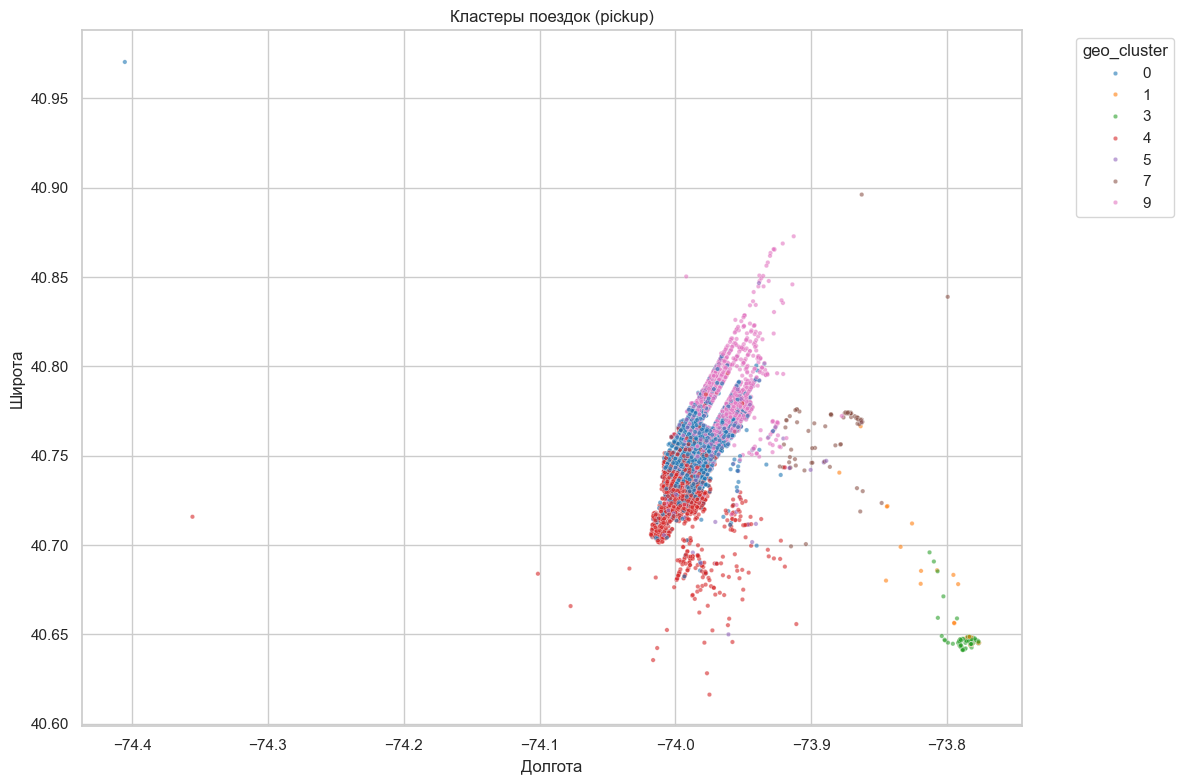

In [610]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# scatter по координатам, цвет — по кластеру
sns.scatterplot(
    data=taxi_data.sample(min(10000, len(taxi_data)), random_state=42),
    x='pickup_longitude',
    y='pickup_latitude',
    hue='geo_cluster',
    palette='tab10',
    s=10,
    alpha=0.6,
    legend='full'
)
plt.title('Кластеры поездок (pickup)')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='geo_cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Задание 2.9.
Реализуйте функцию add_weather_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными о погодных условиях на каждый час;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 5 столбцами:
* temperature - температура;
* visibility - видимость;
* wind speed - средняя скорость ветра;
* precip - количество осадков;
* events - погодные явления.

а) Сколько поездок было совершено в снежную погоду?

В результате объединения у вас должны получиться записи, для которых в столбцах temperature, visibility, wind speed, precip, и events будут пропуски. Это связано с тем, что в таблице с данными о погодных условиях отсутствуют измерения для некоторых моментов времени, в которых включался счетчик поездки. 

б) Сколько процентов от общего количества наблюдений в таблице с данными о поездках занимают пропуски в столбцах с погодными условиями? Ответ приведите с точностью до сотых процента.


In [611]:
weather_data = pd.read_csv('data/weather_data.csv')
weather_data.head()

,time,temperature,windchill,heat index,humidity,pressure,dew Point,visibility,wind dir,wind speed,gust speed,precip,events,conditions,date,hour
0,2015-12-31 02:00:00,7.8,7.1,NaN,0.89,1017.0,6.1,8.0,NNE,5.6,0.0,0.8,NaN,Overcast,2015-12-31,2
1,2015-12-31 03:00:00,7.2,5.9,NaN,0.90,1016.5,5.6,12.9,Variable,7.4,0.0,0.3,NaN,Overcast,2015-12-31,3
2,2015-12-31 04:00:00,7.2,NaN,NaN,0.90,1016.7,5.6,12.9,Calm,0.0,0.0,0.0,NaN,Overcast,2015-12-31,4
3,2015-12-31 05:00:00,7.2,5.9,NaN,0.86,1015.9,5.0,14.5,NW,7.4,0.0,0.0,NaN,Overcast,2015-12-31,5
4,2015-12-31 06:00:00,7.2,6.4,NaN,0.90,1016.2,5.6,11.3,West,5.6,0.0,0.0,NaN,Overcast,2015-12-31,6


In [612]:
# ваш код здесь

def add_weather_features(taxi_df: pd.DataFrame, weather_df: pd.DataFrame) -> pd.DataFrame:
    # Оставляем только нужные столбцы из weather_data
    weather_cols = ['time', 'temperature', 'visibility', 'wind speed', 'precip', 'events']
    weather = weather_df[weather_cols].copy()
    
    # Создаём столбцы date и hour для объединения
    weather['time'] = pd.to_datetime(weather['time'])
    weather['date'] = weather['time'].dt.date
    weather['hour'] = weather['time'].dt.hour
    
    # Удаляем исходный столбец time — он больше не нужен
    weather = weather.drop(columns=['time'])
    
    # Объединяем по дате и часу (left join — сохраняем все поездки)
    df = pd.merge(
        taxi_df,
        weather,
        left_on=['pickup_date', 'pickup_hour'],
        right_on=['date', 'hour'],
        how='left'
    )
    
    # Удаляем вспомогательные столбцы
    df = df.drop(columns=['date', 'hour'])
    
    return df


In [613]:
taxi_data = add_weather_features(taxi_data, weather_data)
taxi_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,total_travel_time,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind speed,precip,events
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,164.9,5.0,1.498521,99.970196,9,4.4,8.0,27.8,0.3,NaN
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,332.0,6.0,1.805507,-117.153768,4,28.9,16.1,7.4,0.0,NaN
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,767.6,16.0,6.385098,-159.680165,4,-6.7,16.1,24.1,0.0,NaN
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,235.8,4.0,1.485498,-172.737700,4,7.2,16.1,25.9,0.0,NaN
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,140.1,5.0,1.188588,179.473585,9,9.4,16.1,9.3,0.0,NaN


In [614]:
print(f"В снежную погоду было совершено {(taxi_data['events']== 'Snow').sum()} поездок")

В снежную погоду было совершено 13126 поездок


In [615]:
weather_cols = ['temperature', 'visibility', 'wind speed', 'precip']

# Маска: True там, где в строке есть хотя бы один пропуск
missing_mask = taxi_data[weather_cols].isna().any(axis=1)

# Доля пропусков в процентах
missing_pct = (missing_mask.sum() / len(taxi_data)) * 100

print(f"{missing_pct:.2f}%")

0.82%


### Задание 2.10.
Реализуйте функцию fill_null_weather_data(), которая принимает на вход которая принимает на вход таблицу с данными о поездках. Функция должна заполнять пропущенные значения в столбцах.

Пропуски в столбцах с погодными условиями -  temperature, visibility, wind speed, precip заполните медианным значением температуры, влажности, скорости ветра и видимости в зависимости от даты начала поездки. Для этого сгруппируйте данные по столбцу pickup_date и рассчитайте медиану в каждой группе, после чего с помощью комбинации методов transform() и fillna() заполните пропуски. 
Пропуски в столбце events заполните строкой 'None' - символом отсутствия погодных явлений (снега/дождя/тумана). 

Пропуски в столбцах с информацией из OSRM API - total_distance, total_travel_time и number_of_steps заполните медианным значением по столбцам. 

Чему равна медиана в столбце temperature после заполнения пропусков? Ответ округлите до десятых.


In [616]:
# ваш код здесь

def fill_null_weather_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Погодные числовые столбцы — заполняем медианой по дате
    weather_numeric_cols = ['temperature', 'visibility', 'wind speed', 'precip']
    for col in weather_numeric_cols:
        df[col] = df[col].fillna(
            df.groupby('pickup_date')[col].transform('median')
        )
    
    # Погодные явления — заполняем 'None'
    df['events'] = df['events'].fillna('None')
    
    # OSRM-столбцы — заполняем медианой по столбцу
    osrm_cols = ['total_distance', 'total_travel_time', 'number_of_steps']
    for col in osrm_cols:
        df[col] = df[col].fillna(df[col].median())
    
    return df

In [617]:
taxi_data = fill_null_weather_data(taxi_data)
# Проверка: считаем оставшиеся пропуски
cols_null_percent = taxi_data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
if cols_with_null.empty:
    print("Пропусков в датасете нет.")
else:
    print("Столбцы с пропусками (в процентах):")
    print(cols_with_null)
    
print(f"Медиана в столбце temperature после заполнения пропусков равна {round(taxi_data['temperature'].median(),1)}")

Пропусков в датасете нет.
Медиана в столбце temperature после заполнения пропусков равна 11.1


В завершение первой части найдем очевидные выбросы в целевой переменной - длительности поездки. 

Проще всего найти слишком продолжительные поездки. Давайте условимся, что выбросами будут считаться поездки, длительность которых превышает 24 часа. 

Чуть сложнее с анализом поездок, длительность которых слишком мала. Потому что к ним относятся действительно реальные поездки на короткие расстояния, поездки, которые были отменены через секунду после того как включился счетчик, а также “телепортации” - перемещение на большие расстояния за считанные секунды. 
Условимся, что мы будем считать выбросами только последнюю группу. Как же нам их обнаружить наиболее простым способом?

Можно воспользоваться информацией о кратчайшем расстоянии, которое проезжает такси. Вычислить среднюю скорость автомобиля на кратчайшем пути следующим образом: 
$$avg\_speed= \frac{total\_distance}{1000*trip\_duration}*3600$$
Если мы построим диаграмму рассеяния средней скорости движения автомобилей, мы увидим следующую картину:


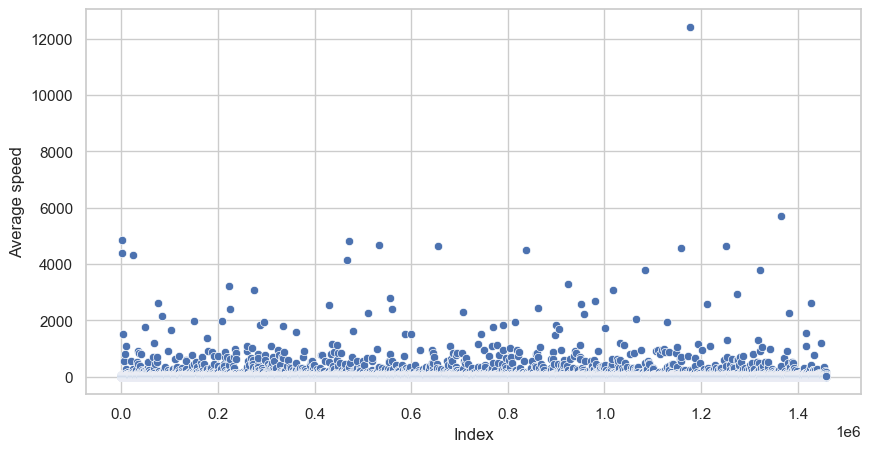

In [618]:
avg_speed = taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax)
ax.set_xlabel('Index')
ax.set_ylabel('Average speed');

Как раз отсюда мы видим, что у нас есть “поездки-телепортации”, для которых средняя скорость более 1000 км/ч. Даже есть такая, средняя скорость которой составляла более 12000 км/ч! 

Давайте условимся, что предельная средняя скорость, которую могут развивать таксисты будет 300 км/ч. 


### Задание 2.11.
Найдите поездки, длительность которых превышает 24 часа. И удалите их из набора данных.

а) Сколько выбросов по признаку длительности поездки вам удалось найти?

Найдите поездки, средняя скорость которых по кратчайшему пути превышает 300 км/ч и удалите их из данных. 

б) Сколько выбросов по признаку скорости вам удалось найти?

In [619]:
# ваш код здесь

threshold_seconds = 24 * 3600  # 86400 секунд
threshold_speed = 300
# Считаем количество выбросов
num_outliers_duration = (taxi_data['trip_duration'] > threshold_seconds).sum()
num_outliers_speed = (avg_speed > threshold_speed).sum()
print(f"Количество выбросов по длительности поездки (>24 часов): {num_outliers_duration}")
print(f"Количество выбросов по скорости поездки (>300 км/ч): {num_outliers_speed}")

# Создаём маску:
mask_to_drop = (taxi_data['trip_duration'] > threshold_seconds) | (avg_speed > threshold_speed)

# Удаляем строки по индексам, где маска True
taxi_data = taxi_data[~mask_to_drop].copy()

Количество выбросов по длительности поездки (>24 часов): 4
Количество выбросов по скорости поездки (>300 км/ч): 407


In [620]:
taxi_data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind speed', 'precip', 'events'],
      dtype='object')

---

## 3. Разведывательный анализ данных (EDA)

В этой части нашего проекта мы с вами:
* Исследуем сформированный набор данных; 
* Попробуем найти закономерности, позволяющие сформулировать предварительные гипотезы относительно того, какие факторы являются решающими в определении длительности поездки;
* Дополним наш анализ визуализациями, иллюстрирующими; исследование. Постарайтесь оформлять диаграммы с душой, а не «для галочки»: навыки визуализации полученных выводов обязательно пригодятся вам в будущем.


Начинаем с целевого признака. Забегая вперед, скажем, что основной метрикой качества решения поставленной задачи будет RMSLE - Root Mean Squared Log Error, которая вычисляется на основе целевой переменной в логарифмическом масштабе. В таком случае целесообразно сразу логарифмировать признак длительности поездки и рассматривать при анализе логарифм в качестве целевого признака:
$$trip\_duration\_log = log(trip\_duration+1),$$
где под символом log подразумевается натуральный логарифм.


In [621]:
taxi_data['trip_duration_log'] = np.log(taxi_data['trip_duration']+1)

### Задание 3.1.
Постройте гистограмму и коробчатую диаграмму длительности поездок в логарифмическом масштабе (trip_duration_log). 
Исходя из визуализации, сделайте предположение, является ли полученное распределение нормальным? 
Проверьте свою гипотезу с помощью теста Д’Агостино при уровне значимости $\alpha=0.05$. 

а) Чему равен вычисленный p-value? Ответ округлите до сотых.

б) Является ли распределение длительности поездок в логарифмическом масштабе нормальным?

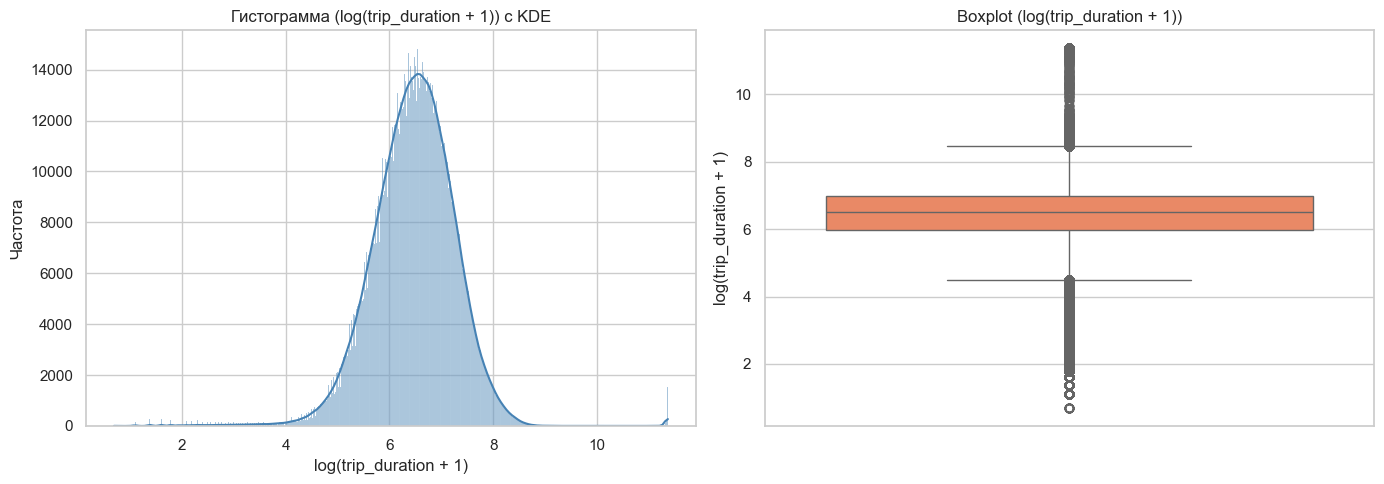

In [622]:
# ваш код здесь
# Настройка стиля графиков
sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с KDE
sns.histplot(
    data=taxi_data,
    x='trip_duration_log',
    kde=True,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Гистограмма (log(trip_duration + 1)) с KDE')
ax[0].set_xlabel('log(trip_duration + 1)')
ax[0].set_ylabel('Частота')

# Коробчатая диаграмма (boxplot)
sns.boxplot(
    y=taxi_data['trip_duration_log'],
    ax=ax[1],
    color='coral'
)
ax[1].set_title('Boxplot (log(trip_duration + 1))')
ax[1].set_ylabel('log(trip_duration + 1)')

plt.tight_layout()
plt.show()

In [623]:
from scipy.stats import normaltest
# Тест Д’Агостино-Пирсона на нормальность
stat, p_value = normaltest(taxi_data['trip_duration_log'])
alpha = 0.05

print(f"Статистика теста: {stat:.4f}")
print(f"P-значение: {p_value:.4e}")

if p_value < alpha:
    print(f"На уровне значимости {alpha} отвергаем гипотезу о нормальности распределения.")
else:
    print(f"На уровне значимости {alpha} нет оснований отвергать гипотезу о нормальности.")

Статистика теста: 138350.1661
P-значение: 0.0000e+00
На уровне значимости 0.05 отвергаем гипотезу о нормальности распределения.


### Задание 3.2.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от таксопарка (vendor_id). 

Сравните два распределения между собой.

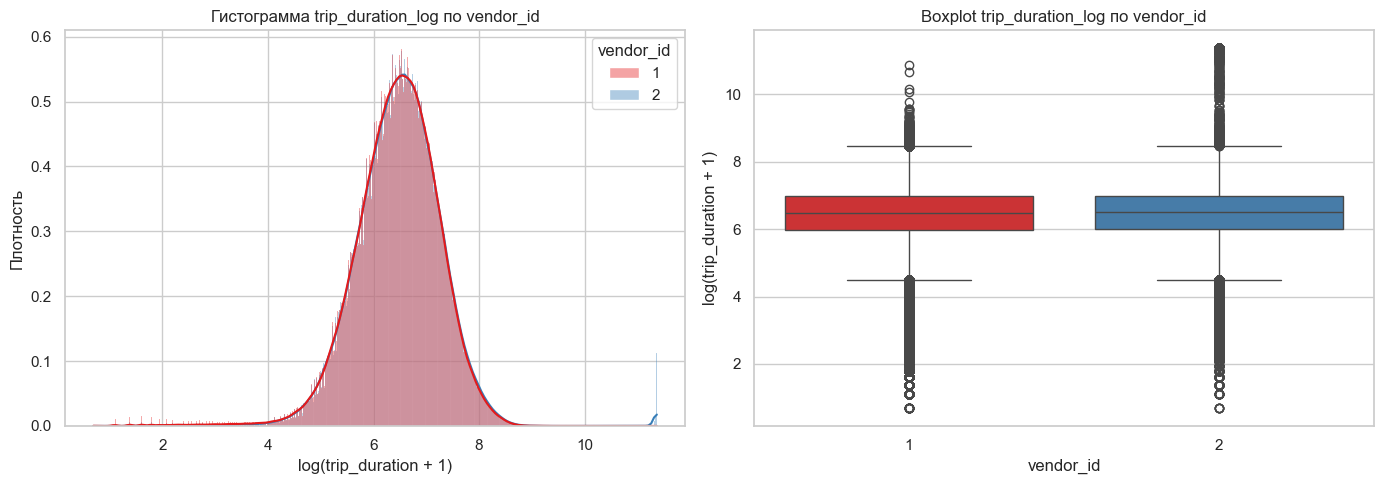

In [624]:
# ваш код здесь
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма: распределение trip_duration_log по таксопаркам
sns.histplot(
    data=taxi_data,
    x='trip_duration_log',
    hue='vendor_id',
    kde=True,
    stat='density',
    common_norm=False,
    ax=ax[0],
    palette='Set1',
    alpha=0.4
)
ax[0].set_title('Гистограмма trip_duration_log по vendor_id')
ax[0].set_xlabel('log(trip_duration + 1)')
ax[0].set_ylabel('Плотность')

# Boxplot: сравнение распределений по таксопаркам
sns.boxplot(
    data=taxi_data,
    x='vendor_id',
    y='trip_duration_log',
    ax=ax[1],
    palette='Set1'
)
ax[1].set_title('Boxplot trip_duration_log по vendor_id')
ax[1].set_xlabel('vendor_id')
ax[1].set_ylabel('log(trip_duration + 1)')

plt.tight_layout()
plt.show()

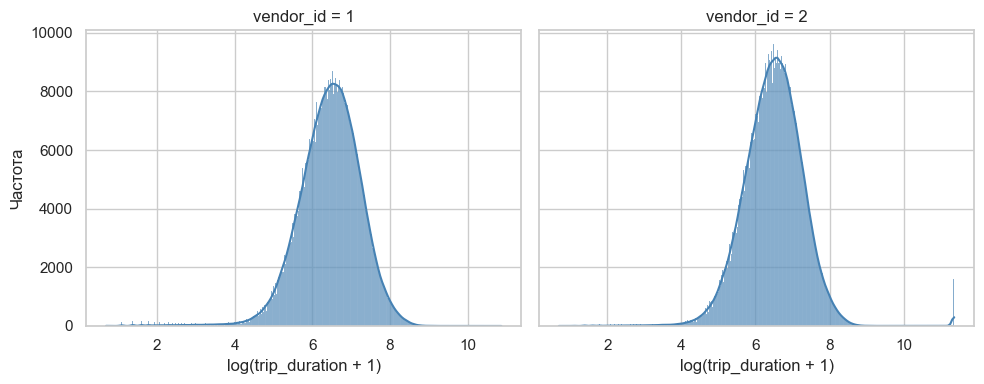

In [625]:
n_vendors = taxi_data['vendor_id'].nunique()
fig, ax = plt.subplots(1, n_vendors, figsize=(5 * n_vendors, 4), sharey=True)

if n_vendors == 1:
    ax = [ax]  # чтобы цикл работал

for i, vid in enumerate(sorted(taxi_data['vendor_id'].unique())):
    subset = taxi_data[taxi_data['vendor_id'] == vid]['trip_duration_log']
    sns.histplot(subset, kde=True, ax=ax[i], color='steelblue', alpha=0.7)
    ax[i].set_title(f'vendor_id = {vid}')
    ax[i].set_xlabel('log(trip_duration + 1)')
    ax[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

### Задание 3.3.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от признака отправки сообщения поставщику (store_and_fwd_flag). 

Сравните два распределения между собой.

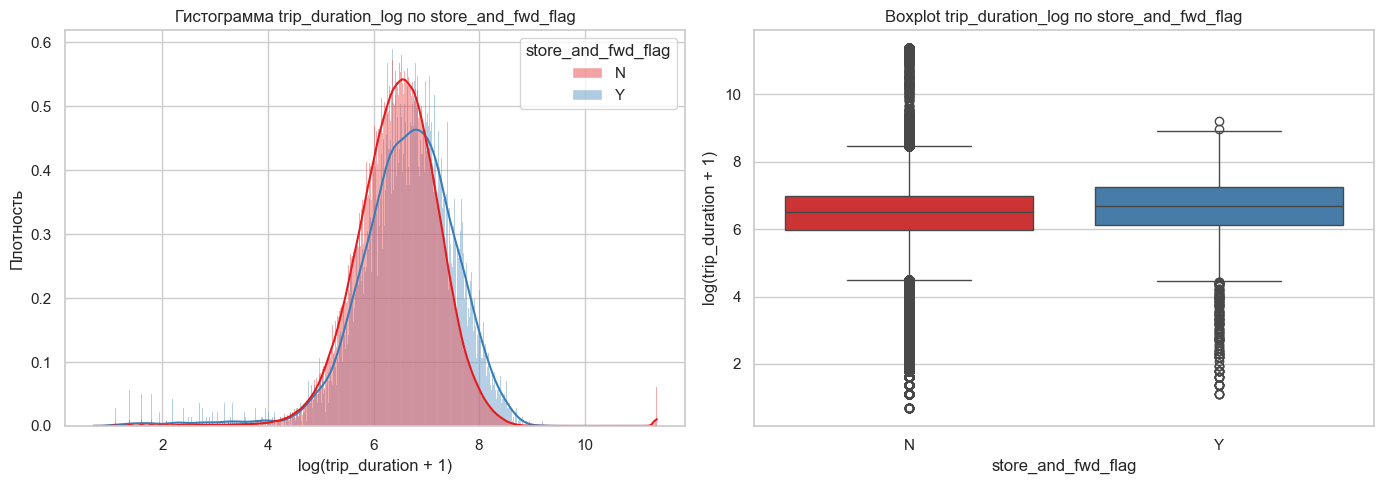

In [626]:
# ваш код здесь

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма: распределение trip_duration_log по store_and_fwd_flag
sns.histplot(
    data=taxi_data,
    x='trip_duration_log',
    hue='store_and_fwd_flag',
    kde=True,
    stat='density',
    common_norm=False,
    ax=ax[0],
    palette='Set1',
    alpha=0.4
)
ax[0].set_title('Гистограмма trip_duration_log по store_and_fwd_flag')
ax[0].set_xlabel('log(trip_duration + 1)')
ax[0].set_ylabel('Плотность')

# Boxplot: сравнение распределений по store_and_fwd_flag
sns.boxplot(
    data=taxi_data,
    x='store_and_fwd_flag',
    y='trip_duration_log',
    ax=ax[1],
    palette='Set1'
)
ax[1].set_title('Boxplot trip_duration_log по store_and_fwd_flag')
ax[1].set_xlabel('store_and_fwd_flag')
ax[1].set_ylabel('log(trip_duration + 1)')

plt.tight_layout()
plt.show()

### Задание 3.4.
Постройте две визуализации:
* Распределение количества поездок в зависимости от часа дня;
* Зависимость медианной длительности поездки от часа дня.

На основе построенных графиков ответьте на следующие вопросы:

а) В какое время суток такси заказывают реже всего?

б) В какое время суток наблюдается пик медианной длительности поездок?

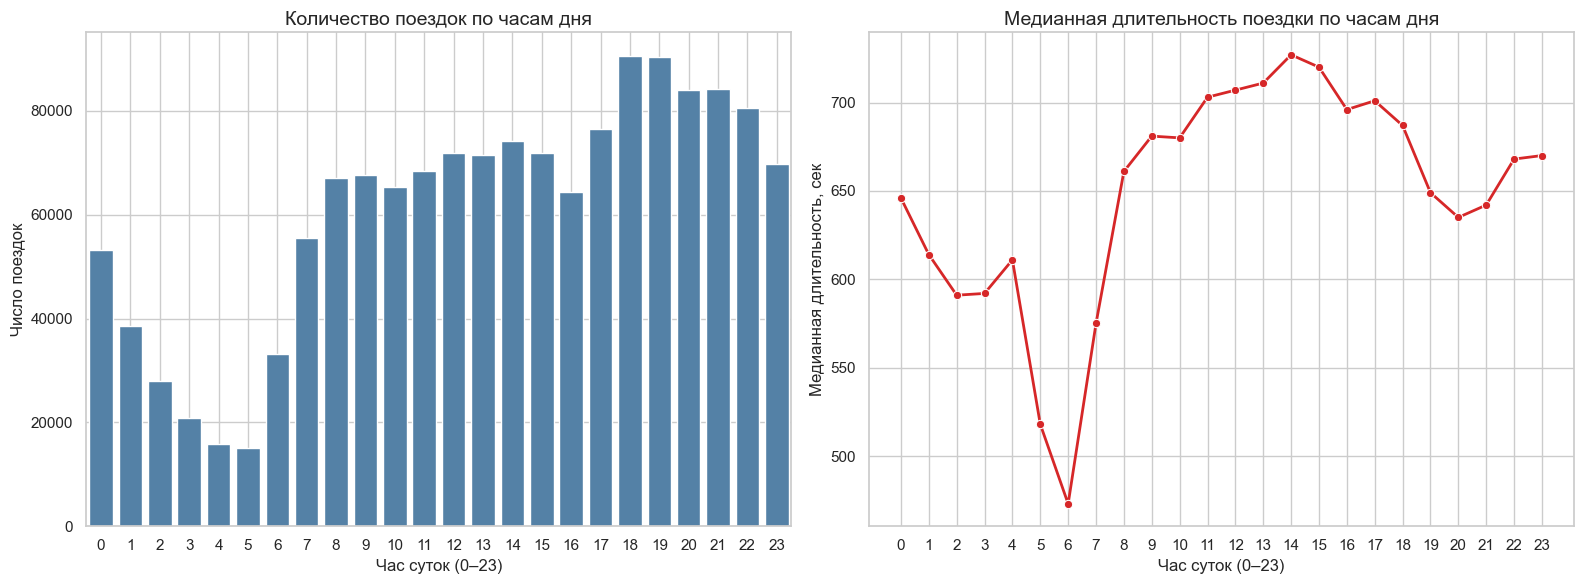

In [627]:
# ваш код здесь
# Убедимся, что pickup_hour — целочисленный тип (на случай, если там float)
taxi_data['pickup_hour'] = taxi_data['pickup_hour'].astype(int)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: количество поездок по часам ---
hour_counts = taxi_data['pickup_hour'].value_counts().sort_index()

sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Количество поездок по часам дня', fontsize=14)
ax[0].set_xlabel('Час суток (0–23)')
ax[0].set_ylabel('Число поездок')
ax[0].set_xticks(range(0, 24, 1))  # метки через 2 часа
ax[0].grid(True)

# --- График 2: медианная длительность поездки по часам ---
median_duration_by_hour = taxi_data.groupby('pickup_hour')['trip_duration'].median()

sns.lineplot(
    x=median_duration_by_hour.index,
    y=median_duration_by_hour.values,
    marker='o',
    linewidth=2,
    markersize=6,
    ax=ax[1],
    color='#d62728'
)
ax[1].set_title('Медианная длительность поездки по часам дня', fontsize=14)
ax[1].set_xlabel('Час суток (0–23)')
ax[1].set_ylabel('Медианная длительность, сек')
ax[1].set_xticks(range(0, 24, 1))

plt.tight_layout()
plt.show()

In [628]:
hour_counts = taxi_data['pickup_hour'].value_counts().sort_index()
# Считаем скользящую сумму по 3 часам, чтобы найти самый тихий 3‑часовой интервал
rolling_3h = hour_counts.rolling(3, min_periods=1, center=True).sum()
quietest_3h_hour = rolling_3h.idxmin()
print(f"Самый тихий 3-х часовой период центрирован на {quietest_3h_hour}:00")

Самый тихий 3-х часовой период центрирован на 4:00


In [629]:
median_by_hour = taxi_data.groupby('pickup_hour')['trip_duration'].median()
peak_hour = median_by_hour.idxmax()
peak_median_duration = median_by_hour.max()

print(f"Пик медианной длительности — в {peak_hour}:00, медиана = {peak_median_duration:.0f} сек ({peak_median_duration/60:.1f} мин).")

Пик медианной длительности — в 14:00, медиана = 727 сек (12.1 мин).


### Задание 3.5.
Постройте две визуализации:
* Распределение количества поездок в зависимости от дня недели;
*  Зависимость медианной длительности поездки от дня недели.

На основе построенных графиков ответьте на следующие вопросы:
а) В какой день недели совершается больше всего поездок?
б) В какой день недели медианная длительность поездок наименьшая?


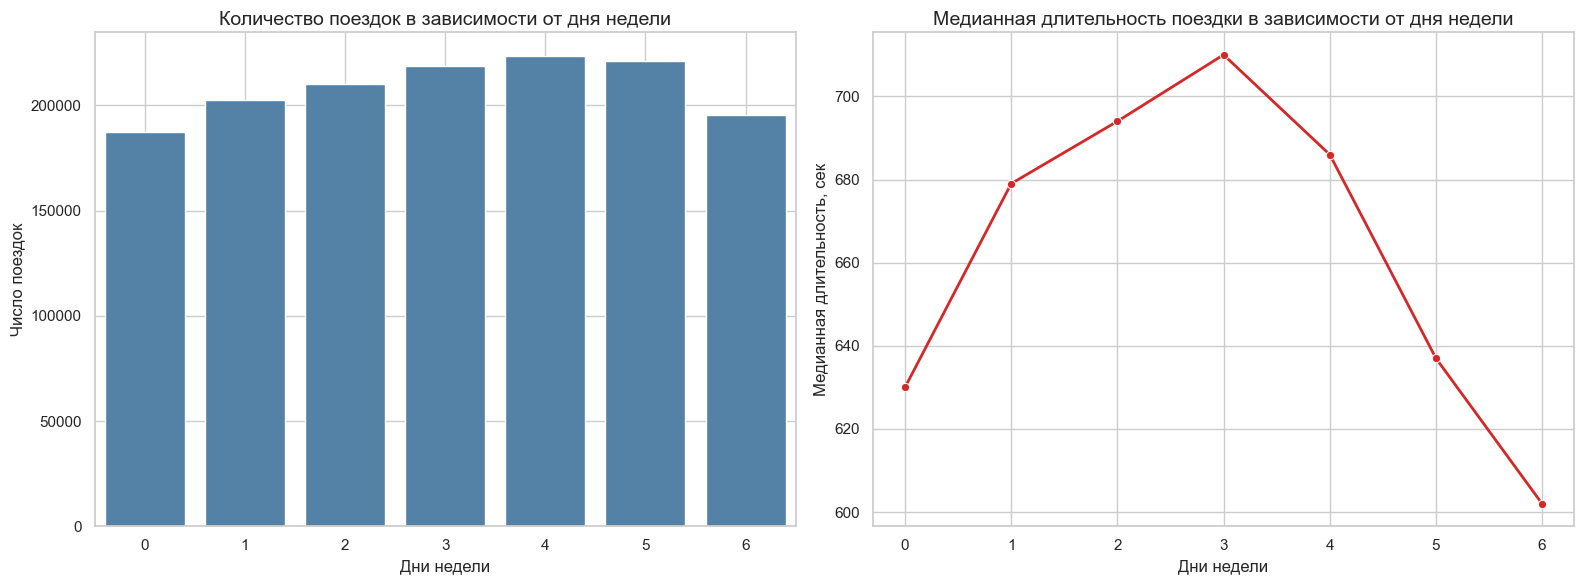

In [630]:
# ваш код здесь
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: распределение количества поездок в зависимости от дня недели ---
day_counts = taxi_data['pickup_day_of_week'].value_counts().sort_index()

sns.barplot(
    x=day_counts.index,
    y=day_counts.values,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Количество поездок в зависимости от дня недели', fontsize=14)
ax[0].set_xlabel('Дни недели')
ax[0].set_ylabel('Число поездок')
ax[0].set_xticks(range(0, 7, 1))  # метки через 2 часа
ax[0].grid(True)

# --- График 2: медианная длительность поездки в зависимости от дня недели ---
median_duration_by_day = taxi_data.groupby('pickup_day_of_week')['trip_duration'].median()

sns.lineplot(
    x=median_duration_by_day.index,
    y=median_duration_by_day.values,
    marker='o',
    linewidth=2,
    markersize=6,
    ax=ax[1],
    color='#d62728'
)
ax[1].set_title('Медианная длительность поездки в зависимости от дня недели', fontsize=14)
ax[1].set_xlabel('Дни недели')
ax[1].set_ylabel('Медианная длительность, сек')
ax[1].set_xticks(range(0, 7, 1))

plt.tight_layout()
plt.show()

In [631]:
# Считаем количество поездок по дням недели
trips_by_day = taxi_data['pickup_day_of_week'].value_counts().sort_index()

# Находим день с максимумом
peak_day_num = trips_by_day.idxmax()
peak_count = trips_by_day.max()

# Словарь для перевода номера дня в название
day_names = {
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'
}

print(f"Больше всего поездок — в {day_names[peak_day_num]}, всего {peak_count:,} поездок.")

Больше всего поездок — в пятница, всего 223,484 поездок.


In [632]:
# Считаем медиану длительности по дням недели
median_by_dow = taxi_data.groupby('pickup_day_of_week')['trip_duration'].median()

# Находим день с минимальной медианой
min_day_num = median_by_dow.idxmin()
min_median_duration = median_by_dow.min()

day_names = {
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'
}

print(f"Наименьшая медианная длительность — в {day_names[min_day_num]}, "
      f"медиана = {min_median_duration:.0f} сек ({min_median_duration/60:.1f} мин).")

Наименьшая медианная длительность — в воскресенье, медиана = 602 сек (10.0 мин).


### Задание 3.6.
Посмотрим на обе временные характеристики одновременно. 

Постройте сводную таблицу, по строкам которой отложены часы (pickup_hour), по столбцам - дни недели (pickup_day_of_week), а в ячейках - медианная длительность поездки (trip_duration). 

Визуализируйте полученную сводную таблицу с помощью тепловой карты (рекомендуемая палитра - coolwarm).

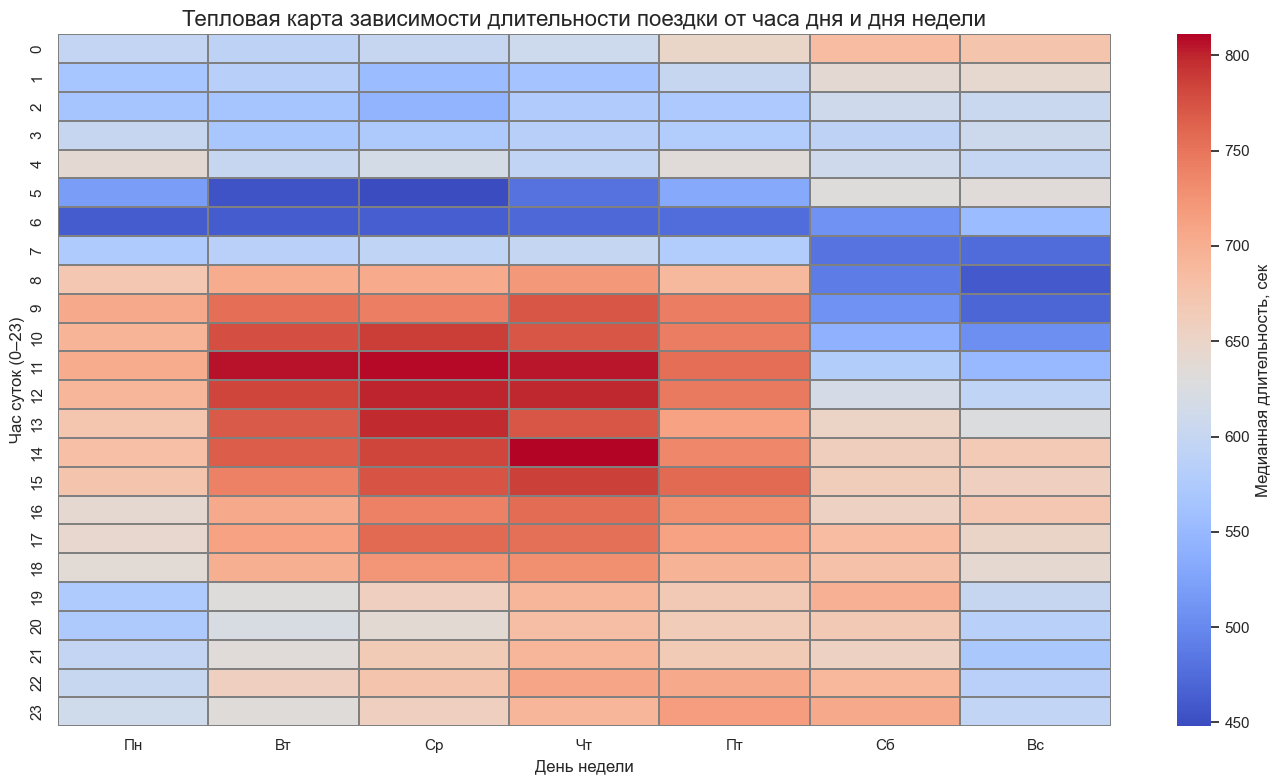

In [633]:
# ваш код здесь

pivot = taxi_data.pivot_table(
    values='trip_duration',
    index='pickup_hour',          # строки: часы 0–23
    columns='pickup_day_of_week', # столбцы: дни недели 0–6
    aggfunc='median',
    fill_value=None                # оставляем NaN там, где нет данных
)

# Переименуем дни для читаемости на графике
day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
pivot = pivot.rename(columns=day_names)

plt.figure(figsize=(14, 8))
heatmap = sns.heatmap(
    data=pivot,
    cmap='coolwarm',
    annot=False,                  # аннотации лучше убрать: 24×7 = 168 ячеек
    cbar_kws={'label': 'Медианная длительность, сек'},
    linewidths=0.1,
    linecolor='gray',
    mask=pivot.isna()             # явно скрываем отсутствующие данные (чтобы не было «белых дыр» с цветом)
)

heatmap.set_title('Тепловая карта зависимости длительности поездки от часа дня и дня недели', fontsize=16)
heatmap.set_xlabel('День недели', fontsize=12)
heatmap.set_ylabel('Час суток (0–23)', fontsize=12)

plt.tight_layout()
plt.show()

### Задание 3.7.
Постройте две диаграммы рассеяния (scatter-диаграммы):
* первая должна иллюстрировать географическое расположение точек начала поездок (pickup_longitude, pickup_latitude) 
* вторая должна географическое расположение точек завершения поездок (dropoff_longitude, dropoff_latitude).

Для этого на диаграммах по оси абсцисс отложите широту (longitude), а по оси ординат - долготу (latitude). 
Включите в визуализацию только те точки, которые находятся в пределах Нью-Йорка - добавьте следующие ограничения на границы осей абсцисс и ординат:
 
city_long_border = (-74.03, -73.75)

city_lat_border = (40.63, 40.85)

Добавьте на диаграммы расцветку по десяти географическим кластерам (geo_cluster), которые мы сгенерировали ранее. 

**Рекомендация:** для наглядности уменьшите размер точек на диаграмме рассеяния.  


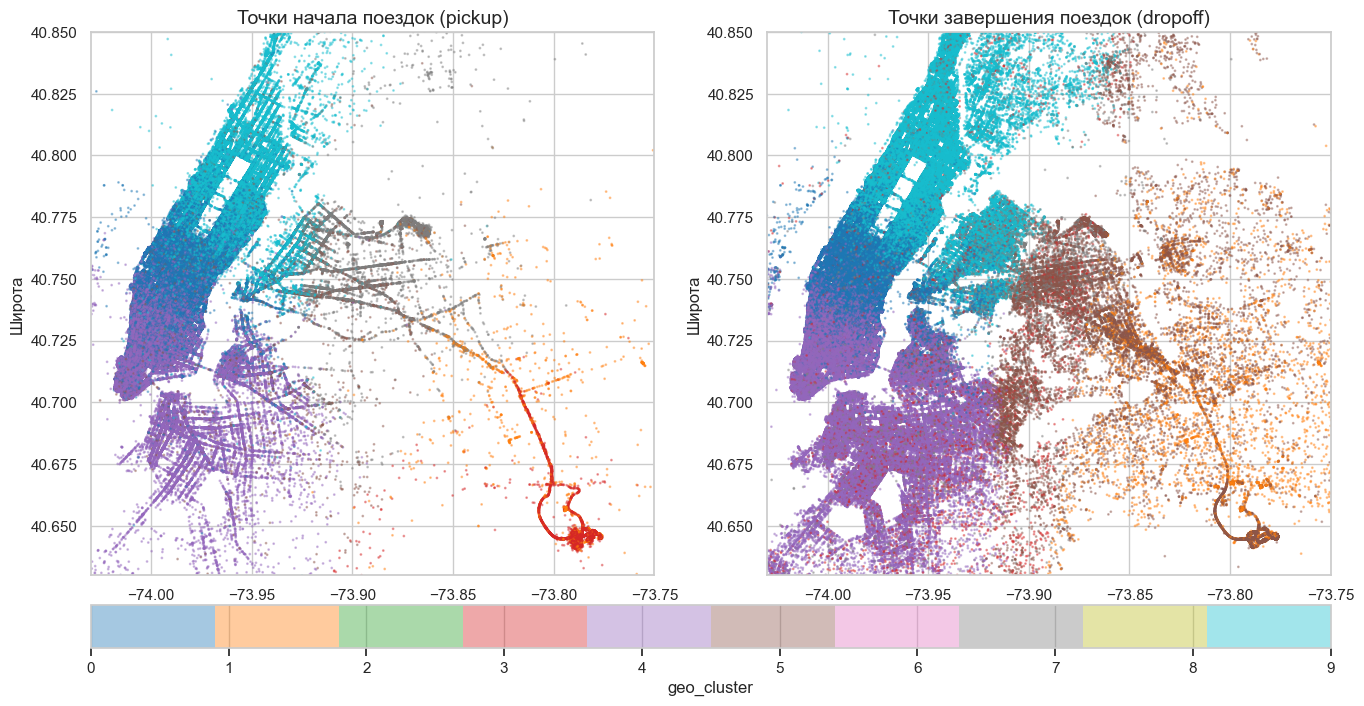

In [634]:
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)

# ваш код здесь
# Создаём фигуру с двумя строками: 1 для графиков, 1 маленькая для colorbar
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.08], wspace=0.2, hspace=0.1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[1, :])  # вся нижняя строка под colorbar

# --- График 1: pickup ---
scatter1 = ax1.scatter(
    taxi_data['pickup_longitude'],
    taxi_data['pickup_latitude'],
    c=taxi_data['geo_cluster'],
    cmap='tab10',
    s=1,
    alpha=0.4
)
ax1.set_xlim(city_long_border)
ax1.set_ylim(city_lat_border)
ax1.set_title('Точки начала поездок (pickup)', fontsize=14)
ax1.set_xlabel('Долгота')
ax1.set_ylabel('Широта')

# --- График 2: dropoff ---
scatter2 = ax2.scatter(
    taxi_data['dropoff_longitude'],
    taxi_data['dropoff_latitude'],
    c=taxi_data['geo_cluster'],
    cmap='tab10',
    s=1,
    alpha=0.4
)
ax2.set_xlim(city_long_border)
ax2.set_ylim(city_lat_border)
ax2.set_title('Точки завершения поездок (dropoff)', fontsize=14)
ax2.set_xlabel('Долгота')
ax2.set_ylabel('Широта')

# --- Горизонтальная colorbar внизу ---
cbar = fig.colorbar(scatter2, cax=cax, orientation='horizontal')
cbar.set_label('geo_cluster', fontsize=12)
cbar.set_ticks(range(10))

plt.tight_layout(rect=[0, 0, 1, 0.95])  # оставляем место сверху, чтобы title не наезжал
plt.show()

In [635]:
# --- Подсчёт кластеров, не попавших в границы Нью-Йорка ---
# Кластер считается "не попавшим", если ни одна его точка не входит в границы
in_nyc = (
    (taxi_data['pickup_longitude'].between(*city_long_border)) &
    (taxi_data['pickup_latitude'].between(*city_lat_border))
)

clusters_in_nyc = set(taxi_data.loc[in_nyc, 'geo_cluster'].unique())
all_clusters = set(taxi_data['geo_cluster'].unique())
missing_clusters = all_clusters - clusters_in_nyc

print(f"Всего кластеров: {len(all_clusters)}")
print(f"Кластеров в границах Нью-Йорка: {len(clusters_in_nyc)}")
print(f"Кластеров за пределами Нью-Йорка: {len(missing_clusters)}")
print(f"Не попали на диаграммы (pickup): {sorted(missing_clusters)}")

# Проверим то же для dropoff
in_nyc_drop = (
    (taxi_data['dropoff_longitude'].between(*city_long_border)) &
    (taxi_data['dropoff_latitude'].between(*city_lat_border))
)
clusters_in_nyc_drop = set(taxi_data.loc[in_nyc_drop, 'geo_cluster'].unique())
missing_drop = all_clusters - clusters_in_nyc_drop
print(f"Не попали на диаграммы (dropoff): {sorted(missing_drop)}")

Всего кластеров: 10
Кластеров в границах Нью-Йорка: 8
Кластеров за пределами Нью-Йорка: 2
Не попали на диаграммы (pickup): [2, 8]
Не попали на диаграммы (dropoff): [2, 6, 8]


Обычно 10 географических кластеров, построенных по координатам Нью-Йорка, примерно соответствуют районам:

**Кластер (ориентировочно)----Район / зона**:
* Манхэттен (центр, север)----	Midtown, Upper Manhattan
* Манхэттен (юг)----	Lower Manhattan, Financial District
* Бруклин (север)----	Williamsburg, Greenpoint
* Бруклин (юг/центр)----	Park Slope, Bedford-Stuyvesant
* Куинс (запад)----	Long Island City, Astoria
* Куинс (восток/юг)----	Jamaica, Far Rockaway
* Бронкс----	The Bronx
* Аэропорт JFK----	JFK Airport (юго-восток)
* Аэропорт Ла-Гуардия----	LGA Airport (север Куинса)
* Нью-Джерси / за пределами----	Newark, Hoboken (за границами карты)

Кластеры, не попавшие на диаграммы, обычно соответствуют:
* поездкам в/из Нью-Джерси (координаты западнее -74.03),
* редким точкам далеко на севере или юге (за пределами 40.63–40.85),
* возможно, ошибочным координатам (например, долгота 0 или широта 0 — артефакты GPS)

* **Кластеры за пределами NYC** — это либо редкие маршруты (Нью-Джерси), либо шум. В пайплайне можно либо оставить их как отдельную категорию, либо объединить в один кластер «outside_nyc».
* **Плотность точек** на диаграмме подсказывает, где больше всего поездок (обычно Манхэттен — самый плотный). Это значит, что ```geo_cluster``` будет хорошим предиктором: поездки внутри Манхэттена короче, из аэропортов — длиннее.
* **Аэропорты (JFK, LGA)** часто выделяются в отдельные кластеры — это полезно: поездки из аэропортов имеют специфическую длительность и маршрут.

---

## 4. Отбор и преобразование признаков

Перед тем как перейти к построению модели, осталось сделать ещё несколько шагов.
* Следует помнить, что многие алгоритмы машинного обучения не могут обрабатывать категориальные признаки в их обычном виде. Поэтому нам необходимо их закодировать;
* Надо отобрать признаки, которые мы будем использовать для обучения модели;
*  Необходимо масштабировать и трансформировать некоторые признаки для того, чтобы улучшить сходимость моделей, в основе которых лежат численные методы.


In [636]:
print('Shape of data: {}'.format(taxi_data.shape))
print('Columns: {}'.format(taxi_data.columns))

Shape of data: (1458233, 27)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind speed', 'precip', 'events',
       'trip_duration_log'],
      dtype='object')


Для удобства работы сделаем копию исходной таблицы с поездками:

In [637]:
train_data = taxi_data.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind speed,precip,events,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,5.0,1.498521,99.970196,9,4.4,8.0,27.8,0.3,None,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6.0,1.805507,-117.153768,4,28.9,16.1,7.4,0.0,None,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,16.0,6.385098,-159.680165,4,-6.7,16.1,24.1,0.0,None,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,4.0,1.485498,-172.737700,4,7.2,16.1,25.9,0.0,None,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5.0,1.188588,179.473585,9,9.4,16.1,9.3,0.0,None,6.077642


### Задание 4.1.
Сразу позаботимся об очевидных неинформативных и избыточных признаках. 

а) Какой из признаков является уникальным для каждой поездки и не несет полезной информации в определении ее продолжительности?

б) Утечка данных (data leak) - это…

в) Подумайте, наличие какого из признаков в обучающем наборе данных создает утечку данных?

г) Исключите выбранные в пунктах а) и в) признаки из исходной таблицы с данными. Сколько столбцов в таблице у вас осталось?


In [638]:
# ваш код здесь
columns_to_drop= ['id','dropoff_datetime']

train_data = train_data.drop(columns_to_drop,axis=1)

In [639]:
print(f"В таблице осталось {train_data.shape[1]} столбцов")

В таблице осталось 25 столбцов


Ранее мы извлекли всю необходимую для нас информацию из даты начала поездки, теперь мы можем избавиться от этих признаков, так как они нам больше не понадобятся:


In [640]:
drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


### Задание 4.2.

Закодируйте признак vendor_id в таблице train_data таким образом, чтобы он был равен 0, если идентификатор таксопарка равен 1, и 1 — в противном случае.

Закодируйте признак store_and_fwd_flag в таблице train_data таким образом, чтобы он был равен 0, если флаг выставлен в значение 'N', и 1 — в противном случае.

а) Рассчитайте среднее по закодированному столбцу vendor_id. Ответ приведите с точностью до сотых.

б) Рассчитайте среднее по закодированному столбцу store_and_fwd_flag. Ответ приведите с точностью до тысячных.



In [641]:
# ваш код здесь
mapping1 = {1: 0, 2: 1} 
train_data['vendor_id'] = train_data['vendor_id'].map(mapping1)
mapping2 = {'N': 0, 'Y': 1} 
train_data['store_and_fwd_flag'] = train_data['store_and_fwd_flag'].map(mapping2)

In [642]:
print(f"Среднее по закодированному столбцу vendor_id: {round(train_data['vendor_id'].mean(),2)}")
print(f"Среднее по закодированному столбцу store_and_fwd_flag: {round(train_data['store_and_fwd_flag'].mean(),3)}")

Среднее по закодированному столбцу vendor_id: 0.53
Среднее по закодированному столбцу store_and_fwd_flag: 0.006


### Задание 4.3.
Создайте таблицу data_onehot из закодированных однократным кодированием признаков pickup_day_of_week, geo_cluster и events в таблице train_data с помощью OneHotEncoder из библиотеки sklearn. Параметр drop выставите в значение 'first', чтобы удалять первый бинарный столбец, тем самым не создавая излишних признаков.

В параметре handle_unknown установите значение 'ignore'. Это позволит коду отработать без ошибок в случае появления в тестовой выборке значений, отсутствующих в обучающей выборке.

В результате работы OneHotEncoder вы получите безымянный numpy-массив, который нам будет необходимо преобразовать обратно в DataFrame, для более удобной работы в дальнейшем. Чтобы получить имена закодированных столбцов у объекта типа OneHotEncoder есть специальный метод get_feature_names_out(). Он возвращает список новых закодированных имен столбцов в формате <оригинальное имя столбца>_<имя категории>.

Пример использования:

``` python
# Объявляем кодировщик
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
# Получаем закодированные имена столбцов
column_names = one_hot_encoder.get_feature_names_out()
# Составляем DataFrame из закодированных признаков
data_onehot = pd.DataFrame(data_onehot, columns=column_names)
```

В этом псевдокоде:
* one_hot_encoder - объект класса OneHotEncoder
* data_onehot - numpy-массив, полученный в результате трансформации кодировщиком

В результате выполнения задания у вас должен быть образован DataFrame `data_onehot`, который содержит кодированные категориальные признаки pickup_day_of_week, geo_cluster и events. 


Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования?


In [643]:
# ваш код здесь
from sklearn.preprocessing import OneHotEncoder
columns_to_change = ['pickup_day_of_week','geo_cluster','events']
# Объявляем кодировщик 
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

# 'учим' и сразу применяем преобразование к выборке, результат переводим в массив
data_onehot = one_hot_encoder.fit_transform(train_data[columns_to_change]).toarray()
# Получаем закодированные имена столбцов
column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
data_onehot = pd.DataFrame(data_onehot, columns=column_names)
data_onehot.head()

,pickup_day_of_week_1,pickup_day_of_week_2,pickup_day_of_week_3,pickup_day_of_week_4,pickup_day_of_week_5,pickup_day_of_week_6,geo_cluster_1,geo_cluster_2,geo_cluster_3,geo_cluster_4,geo_cluster_5,geo_cluster_6,geo_cluster_7,geo_cluster_8,geo_cluster_9,events_None,events_Rain,events_Snow
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [644]:
print(f"Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования? - {data_onehot.shape[1]}")

Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования? - 18


Добавим полученную таблицу с закодированными признаками:

In [645]:
train_data = pd.concat(
    [train_data.reset_index(drop=True).drop(columns_to_change, axis=1), data_onehot], 
    axis=1
)
print('Shape of data: {}'.format(train_data.shape))

Shape of data: (1458233, 38)


Теперь, когда категориальные признаки предобработаны, сформируем матрицу наблюдений X, вектор целевой переменной y и его логарифм y_log. В матрицу наблюдений войдут все столбцы из таблицы с поездками за исключением целевого признака trip_duration и его логарифмированной версии trip_duration_log:


In [646]:
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

Все наши модели мы будем обучать на логарифмированной версии y_log. 

Выбранный тип валидации - hold-out. Разобьем выборку на обучающую и валидационную в соотношении 67/33:

In [647]:
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log, 
    test_size=0.33, 
    random_state=42
)

На данный момент у нас достаточно много признаков: скорее всего, не все из них будут важны. Давайте оставим лишь те, которые сильнее всего связаны с целевой переменной и точно будут вносить вклад в повышение качества модели.


### Задание 4.4.
С помощью SelectKBest отберите 25 признаков, наилучшим образом подходящих для предсказания целевой переменной в логарифмическом масштабе. Отбор реализуйте по обучающей выборке, используя параметр score_func = f_regression.

Укажите признаки, которые вошли в список отобранных


In [648]:
# ваш код здесь
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=25)
selector.fit(X_train, y_train_log)

# Получаем маску отобранных признаков
selected_mask = selector.get_support()

# Имена отобранных колонок
selected_features = X_train.columns[selected_mask]
print("Отобранные признаки:", selected_features.tolist())

# Применяем к train и valid (только transform!)
X_train = X_train[selected_features]
X_valid = X_valid[selected_features]   # валидацию берём теми же колонками

print("Формы:", X_train.shape, X_valid.shape)


Отобранные признаки: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_holiday', 'total_distance', 'total_travel_time', 'number_of_steps', 'haversine_distance', 'temperature', 'pickup_day_of_week_1', 'pickup_day_of_week_2', 'pickup_day_of_week_3', 'pickup_day_of_week_4', 'pickup_day_of_week_5', 'pickup_day_of_week_6', 'geo_cluster_1', 'geo_cluster_3', 'geo_cluster_5', 'geo_cluster_7', 'geo_cluster_9']
Формы: (977016, 25) (481217, 25)


Так как мы будем использовать различные модели, в том числе внутри которых заложены численные методы оптимизации, то давайте заранее позаботимся о масштабировании факторов. 


### Задание 4.5.
Нормализуйте предикторы в обучающей и валидационной выборках с помощью MinMaxScaler из библиотеки sklearn. Помните, что обучение нормализатора производится на обучающей выборке, а трансформация на обучающей и валидационной!

Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из валидационной выборки. Ответ округлите до сотых.


In [649]:
# ваш код здесь
from sklearn.preprocessing import MinMaxScaler

# Скалер: fit на train, transform на train и valid
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Конвертация в DataFrame с сохранением имён колонок и индексов
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    columns=X_valid.columns,
    index=X_valid.index
)

# Среднее арифметическое первого предиктора (столбец 0) валидационной выборки
mean_first_predictor = X_valid_scaled.iloc[:, 0].mean()
mean_first_predictor_rounded = round(mean_first_predictor, 2)

print(f"Среднее арифметическое первого предиктора валидационной выборки: {mean_first_predictor_rounded}")

Среднее арифметическое первого предиктора валидационной выборки: 0.54


## 5. Решение задачи регрессии: линейная регрессия и деревья решений

Определим метрику, по которой мы будем измерять качество наших моделей. Мы будем следовать канонам исходного соревнования на Kaggle и в качестве метрики использовать RMSLE (Root Mean Squared Log Error), которая вычисляется как:
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$
где:
* $y_i$ - истинная длительность i-ой поездки на такси (trip_duration)
* $\hat{y_i}$- предсказанная моделью длительность i-ой поездки на такси

Заметим, что логарифмирование целевого признака мы уже провели заранее, поэтому нам будет достаточно вычислить метрику RMSE для модели, обученной прогнозировать длительность поездки такси в логарифмическом масштабе:
$$z_i=log(y_i+1),$$
$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$



### Задание 5.1.
Постройте модель линейной регрессии на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [650]:
# ваш код здесь

from sklearn.linear_model import LinearRegression
#Создаём объект класса LinearRegression
lr1 = linear_model.LinearRegression()
#Обучаем модель — ищем параметры по МНК
lr1.fit(X_train_scaled, y_train_log)

# Предсказания (в логарифмическом масштабе)
y_pred_train_log = lr1.predict(X_train_scaled)
y_pred_valid_log = lr1.predict(X_valid_scaled)

# Рассчет метрики

rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

print(f"RMSLE train: {round(rmsle_train, 2)}")
print(f"RMSLE valid: {round(rmsle_valid, 2)}")

RMSLE train: 0.54
RMSLE valid: 0.54


### Задание 5.2.
Сгенерируйте полиномиальные признаки 2-ой степени с помощью PolynomialFeatures из библиотеки sklearn. Параметр include_bias выставите в значение False.

Постройте модель полиномиальной регрессии 2-ой степени на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [651]:
# ваш код здесь
from sklearn import preprocessing
#Создаём генератор полиномиальных признаков
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train_scaled)
#Генерируем полиномиальные признаки для тренировочной выборки
X_train_poly = poly.transform(X_train_scaled)
#Генерируем полиномиальные признаки для тестовой выборки
X_valid_poly = poly.transform(X_valid_scaled)
#Выводим результирующие размерности таблиц
print(X_train_poly.shape)
print(X_valid_poly.shape)

(977016, 350)
(481217, 350)


In [652]:
lr2 = linear_model.LinearRegression()
#Обучаем модель — ищем параметры по МНК
lr2.fit(X_train_poly, y_train_log)

# Предсказания (в логарифмическом масштабе)
y_pred_train_log = lr2.predict(X_train_poly)
y_pred_valid_log = lr2.predict(X_valid_poly)

# Рассчет метрики

rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

print(f"RMSLE train: {round(rmsle_train, 2)}")
print(f"RMSLE valid: {round(rmsle_valid, 2)}")

RMSLE train: 0.47
RMSLE valid: 0.7


### Задание 5.3.
Постройте модель полиномиальной регрессии 2-ой степени с L2-регуляризацией (регуляризация по Тихонову) на обучающей выборке  (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Коэффициент регуляризации $\alpha$ установите равным 1, остальные параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [653]:
# ваш код здесь
#Создаём объект класса линейной регрессии с L2-регуляризацией
lr3_ridge = linear_model.Ridge(alpha=1)
#Обучаем модель
lr3_ridge.fit(X_train_poly, y_train_log)

#Делаем предсказание для тренировочной выборки
y_pred_train_log = lr3_ridge.predict(X_train_poly)
#Делаем предсказание для тестовой выборки
y_pred_valid_log = lr3_ridge.predict(X_valid_poly)

# Рассчет метрики

rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

print(f"RMSLE train: {round(rmsle_train, 2)}")
print(f"RMSLE valid: {round(rmsle_valid, 2)}")

RMSLE train: 0.48
RMSLE valid: 0.48


### Задание 5.4.
Постройте модель дерева решений (DecisionTreeRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию. 

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [654]:
# ваш код здесь

from sklearn.tree import DecisionTreeRegressor
# Построение модели дерева решений для регрессии
dt = DecisionTreeRegressor(random_state=42)  
dt.fit(X_train_scaled, y_train_log)

# Предсказания на обучающей и валидационной выборках
y_pred_train_log = dt.predict(X_train_scaled)
y_pred_valid_log = dt.predict(X_valid_scaled)

# Рассчет метрики

rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

print(f"RMSLE train: {round(rmsle_train, 2)}")
print(f"RMSLE valid: {round(rmsle_valid, 2)}")

RMSLE train: 0.0
RMSLE valid: 0.57


### Задание 5.5.
Переберите все возможные варианты глубины дерева решений в диапазоне от 7 до 20:

max_depths = range(7, 20)

Параметр random_state задайте равным 42.

Постройте линейные графики изменения метрики RMSE на тренировочной и валидационной выборках в зависимости от значения параметра глубины дерева решений. 

а) Найдите оптимальное значение максимальной глубины дерева, для которой будет наблюдаться минимальное значение RMSLE на обучающей выборке, но при этом еще не будет наблюдаться переобучение (валидационная кривая еще не начинает возрастать).

б) Чему равно значение метрик RMSLE на тренировочной и валидационной выборках для дерева решений с выбранной оптимальной глубиной? Ответ округлите до сотых.


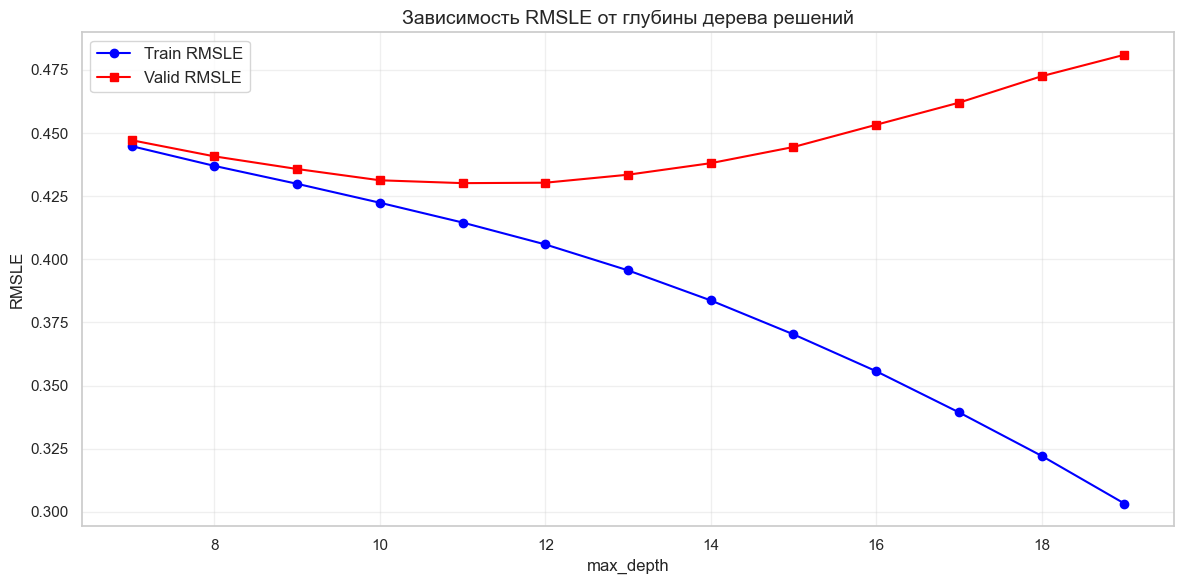

Оптимальная глубина (минимум valid RMSLE): 11
RMSLE train при max_depth=11: 0.4146
RMSLE valid при max_depth=11: 0.4302

--- Полная таблица ---
max_depth= 7 | train RMSLE=0.4448 | valid RMSLE=0.4472
max_depth= 8 | train RMSLE=0.4370 | valid RMSLE=0.4408
max_depth= 9 | train RMSLE=0.4299 | valid RMSLE=0.4358
max_depth=10 | train RMSLE=0.4224 | valid RMSLE=0.4313
max_depth=11 | train RMSLE=0.4146 | valid RMSLE=0.4302
max_depth=12 | train RMSLE=0.4059 | valid RMSLE=0.4303
max_depth=13 | train RMSLE=0.3956 | valid RMSLE=0.4335
max_depth=14 | train RMSLE=0.3837 | valid RMSLE=0.4381
max_depth=15 | train RMSLE=0.3703 | valid RMSLE=0.4445
max_depth=16 | train RMSLE=0.3557 | valid RMSLE=0.4533
max_depth=17 | train RMSLE=0.3394 | valid RMSLE=0.4620
max_depth=18 | train RMSLE=0.3221 | valid RMSLE=0.4725
max_depth=19 | train RMSLE=0.3033 | valid RMSLE=0.4810


In [655]:
# ваш код здесь
max_depths = range(7, 20)

rmsle_train_list = []
rmsle_valid_list = []

for depth in max_depths:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_train_scaled, y_train_log)

    y_pred_train_log = reg.predict(X_train_scaled)
    y_pred_valid_log = reg.predict(X_valid_scaled)

    # Рассчет метрики

    rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
    rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

    rmsle_train_list.append(rmsle_train)
    rmsle_valid_list.append(rmsle_valid)

# --- Линейный график ---
plt.figure(figsize=(12, 6))
plt.plot(list(max_depths), rmsle_train_list, marker='o', label='Train RMSLE', color='blue')
plt.plot(list(max_depths), rmsle_valid_list, marker='s', label='Valid RMSLE', color='red')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('RMSLE', fontsize=12)
plt.title('Зависимость RMSLE от глубины дерева решений', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Поиск оптимальной глубины ---
# Оптимум = точка, где valid RMSLE минимален (до того, как кривая начинает расти)
best_idx = np.argmin(rmsle_valid_list)
best_depth = list(max_depths)[best_idx]

print(f"Оптимальная глубина (минимум valid RMSLE): {best_depth}")
print(f"RMSLE train при max_depth={best_depth}: {rmsle_train_list[best_idx]:.4f}")
print(f"RMSLE valid при max_depth={best_depth}: {rmsle_valid_list[best_idx]:.4f}")

# Вывод всех значений для анализа
print("\n--- Полная таблица ---")
for i, depth in enumerate(max_depths):
    print(f"max_depth={depth:2d} | train RMSLE={rmsle_train_list[i]:.4f} | valid RMSLE={rmsle_valid_list[i]:.4f}")

## 6. Решение задачи регрессии: ансамблевые методы и построение прогноза

Переходим к тяжелой артиллерии: ансамблевым алгоритмам. 

### Задание 6.1.

Постройте модель случайного леса на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* n_estimators=200,
* max_depth=12,
* criterion='squared_error',
* min_samples_split=20,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [656]:
# ваш код здесь
#Создаём объект класса RandomForestClassifier
rf1 = ensemble.RandomForestRegressor(
    n_estimators=200, #число деревьев
    criterion='squared_error', #критерий эффективности
    max_depth=12, #максимальная глубина дерева
    min_samples_split = 20,
    random_state=42, #генератор случайных чисел
    verbose=1,
    n_jobs=-1
)
#Обучаем модель 
rf1.fit(X_train_scaled, y_train_log)
 
#Делаем предсказание 
y_pred_train_log = rf1.predict(X_train_scaled)
y_pred_valid_log = rf1.predict(X_valid_scaled)

# Рассчет метрики

rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   22.2s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.4min finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    1.7s
[Parallel(n_jobs=18)]: Done 200 out of 200 | elapsed:    2.0s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    0.7s
[Parallel(n_jobs=18)]: Done 200 out of 200 | elapsed:    0.9s finished


In [657]:
print(f"RMSLE train: {round(rmsle_train, 2)}")
print(f"RMSLE valid: {round(rmsle_valid, 2)}")

RMSLE train: 0.4
RMSLE valid: 0.41


### Задание 6.2.
Постройте модель градиентного бустинга над деревьями решений (GradientBoostingRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* learning_rate=0.5,
* n_estimators=100,
* max_depth=6, 
* min_samples_split=30,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [658]:
# ваш код здесь
from sklearn.ensemble import GradientBoostingRegressor

# Создаем объект класса градиентный бустинг
gb = GradientBoostingRegressor(
    learning_rate = 0.5,
    n_estimators = 100,
    max_depth = 6,
    min_samples_split = 30,
    random_state = 42,
    verbose=1
)

# Обучаем модель
gb.fit(X_train_scaled, y_train_log)

#Делаем предсказание 
y_pred_train_log = gb.predict(X_train_scaled)
y_pred_valid_log = gb.predict(X_valid_scaled)

# Рассчет метрики

rmsle_train = np.sqrt(np.mean((y_pred_train_log - y_train_log) ** 2))
rmsle_valid = np.sqrt(np.mean((y_pred_valid_log - y_valid_log) ** 2))

print(f"RMSLE train: {round(rmsle_train, 2)}")
print(f"RMSLE valid: {round(rmsle_valid, 2)}")

      Iter       Train Loss   Remaining Time 
         1           0.3110           12.24m
         2           0.2247           11.30m
         3           0.1987           10.78m
         4           0.1876           10.47m
         5           0.1823           10.30m
         6           0.1783           10.11m
         7           0.1756            9.95m
         8           0.1730            9.75m
         9           0.1709            9.56m
        10           0.1696            9.41m
        20           0.1577            8.06m
        30           0.1538            6.89m
        40           0.1502            5.85m
        50           0.1480            4.89m
        60           0.1451            3.91m
        70           0.1431            2.93m
        80           0.1410            1.95m
        90           0.1393           58.53s
       100           0.1383            0.00s
RMSLE train: 0.37
RMSLE valid: 0.39


### Задание 6.3.
Какая из построенных вами моделей показала наилучший результат (наименьшее значение RMSLE на валидационной выборке)?
* Линейная регрессия
* Полиномиальная регрессия 2ой степени
* Дерево решений
* Случайный лес
* Градиентный бустинг над деревьями решений


### Задание 6.4.
Постройте столбчатую диаграмму коэффициентов значимости каждого из факторов.

Укажите топ-3 наиболее значимых для предсказания целевого признака - длительности поездки в логарифмическом масштабе - факторов.


Топ-3 наиболее значимых признака:
              feature  importance
9      total_distance    0.628963
10  total_travel_time    0.187075
7         pickup_hour    0.059600


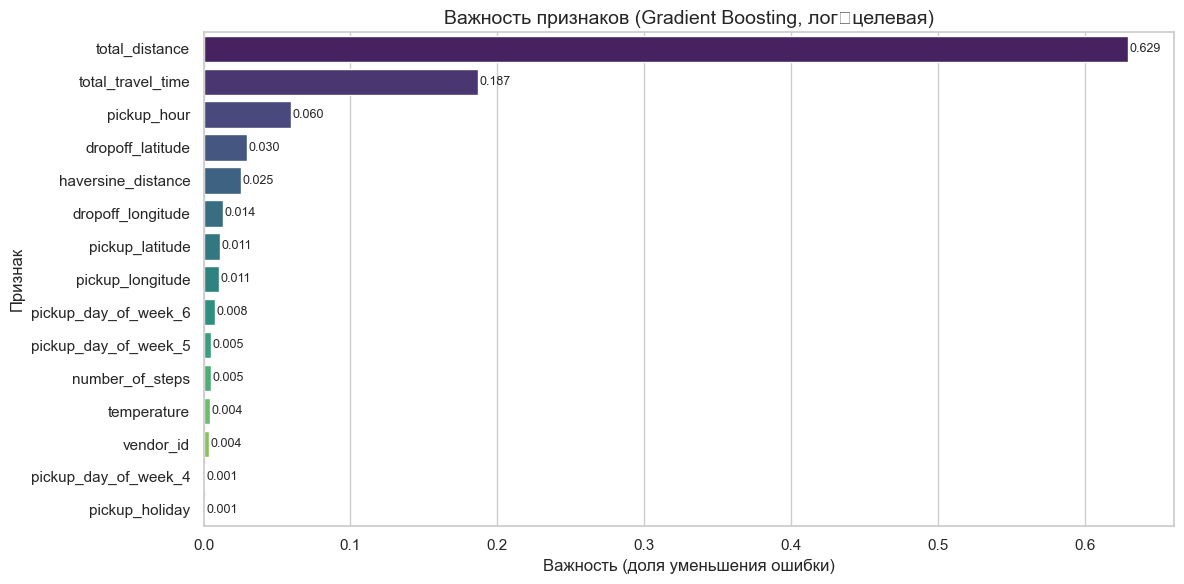

In [659]:
# ваш код здесь
import warnings
warnings.filterwarnings('ignore')
# Получаем важность признаков и имена колонок
importances = gb.feature_importances_
features = X_train_scaled.columns

# Создаём DataFrame для удобной сортировки
feat_imp_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Топ‑3 признака
top_3 = feat_imp_df.head(3)
print("Топ-3 наиболее значимых признака:")
print(top_3)

# Строим график только для топ‑N (например, топ‑15), чтобы было читаемо
N_show = 15  # можно поменять на другое число
top_to_plot = feat_imp_df.head(N_show)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_to_plot, x='importance', y='feature', ax=ax, palette='viridis')

ax.set_title('Важность признаков (Gradient Boosting, лог‑целевая)', fontsize=14)
ax.set_xlabel('Важность (доля уменьшения ошибки)', fontsize=12)
ax.set_ylabel('Признак', fontsize=12)

# Добавим числовые значения на столбцы для наглядности
for i, row in enumerate(top_to_plot.itertuples(index=False)):
    ax.text(row.importance + 0.001, i, f'{row.importance:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Задание 6.5.
Для лучшей из построенных моделей рассчитайте медианную абсолютную ошибку (MeAE - в sklearn функция median_absolute_error) предсказания длительности поездки такси на валидационной выборке:
$$ MeAE = median(|y_i-\hat{y_i}|)$$

Значение метрики MeAE переведите в минуты и округлите до десятых.


In [660]:
# ваш код здесь
from sklearn.metrics import median_absolute_error

# 1. Обратное преобразование: из лог-масштаба в секунды
y_pred_valid_sec = np.exp(y_pred_valid_log) - 1
y_valid_sec = np.exp(y_valid_log) - 1

# 2. Перевод из секунд в минуты (делим на 60)
y_pred_valid_min = y_pred_valid_sec / 60
y_valid_min = y_valid_sec / 60

# 3. Расчёт MeAE
meae = median_absolute_error(y_valid_min, y_pred_valid_min)

print(f"MeAE на валидационной выборке: {round(meae, 1)} минут")

MeAE на валидационной выборке: 1.8 минут


Финальный шаг - сделать submit -  предсказание для отложенного тестового набора данных. 

Прочитаем тестовые данные и заранее выделим столбец с идентификаторами поездок из тестового набора данных. Он нам еще пригодится:


In [661]:
test_data = pd.read_csv("data/Project5_test_data.csv")
osrm_data_test = pd.read_csv("data/Project5_osrm_data_test.csv")
test_id = test_data['id']

Перед созданием прогноза для тестовой выборки необходимо произвести все манипуляции с данными, которые мы производили с тренировочной выборкой, а именно:
* Перевести признак pickup_datetime в формат datetime;
* Добавить новые признаки (временные, географические, погодные и другие факторы);
* Произвести очистку данных от пропусков;
* Произвести кодировку категориальных признаков:
    * Закодировать бинарные признаки;
    * Закодировать номинальные признаки с помощью обученного на тренировочной выборке OneHotEncoder’а;
* Сформировать матрицу наблюдений, оставив в таблице только те признаки, которые были отобраны с помощью SelectKBest;
* Нормализовать данные с помощью обученного на тренировочной выборке MinMaxScaler’а.


In [662]:
test_data['pickup_datetime']=pd.to_datetime(test_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')
test_data = add_datetime_features(test_data)
test_data = add_holiday_features(test_data, holiday_data)
test_data = add_osrm_features(test_data, osrm_data_test)
test_data = add_geographical_features(test_data)
test_data = add_cluster_features(test_data, kmeans)
test_data = add_weather_features(test_data, weather_data)
test_data = fill_null_weather_data(test_data)
test_data['vendor_id'] = test_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)
test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)
test_data_onehot = one_hot_encoder.transform(test_data[columns_to_change]).toarray()
column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
test_data_onehot = pd.DataFrame(test_data_onehot, columns=column_names)

test_data = pd.concat(
    [test_data.reset_index(drop=True).drop(columns_to_change, axis=1), test_data_onehot], 
    axis=1
)
X_test = test_data[selected_features]
X_test_scaled = scaler.transform(X_test)
print('Shape of data: {}'.format(X_test.shape))

Shape of data: (625134, 25)


Только после выполнения всех этих шагов можно сделать предсказание длительности поездки для тестовой выборки. Не забудьте перевести предсказания из логарифмического масштаба в истинный, используя формулу:
$$y_i=exp(z_i)-1$$

После того, как вы сформируете предсказание длительности поездок на тестовой выборке вам необходимо будет создать submission-файл в формате csv, отправить его на платформу Kaggle и посмотреть на результирующее значение метрики RMSLE на тестовой выборке.




In [663]:
# Предсказание
y_test_pred_log = gb.predict(X_test_scaled)
y_test_predict = np.exp(y_test_pred_log) - 1
y_test_predict = np.maximum(y_test_predict, 0)

In [664]:
# Предсказание на валидации
y_valid_pred_log = gb.predict(X_valid_scaled)
rmsle_valid = np.sqrt(np.mean((y_valid_pred_log - y_valid_log) ** 2))
print(f"RMSLE valid: {rmsle_valid:.4f}")

RMSLE valid: 0.3941


Код для создания submission-файла:

In [665]:
# ваш код здесь
submission = pd.DataFrame({'id': test_id, 'trip_duration': y_test_predict})
submission.to_csv('data/submission_gb.csv', index=False)

### **В качестве бонуса**

В завершение по ансамблевым мы предлагаем вам попробовать улучшить свое предсказание, воспользовавшись моделью экстремального градиентного бустинга (XGBoost) из библиотеки xgboost.

**XGBoost** - современная модель машинного обучения, которая является продолжением идеи градиентного бустинга Фридмана. У нее есть несколько преимуществ по сравнению с классической моделью градиентного бустинга из библиотеки sklearn: повышенная производительность путем параллелизации процесса обучения, повышенное качество решения за счет усовершенствования алгоритма бустинга, меньшая склонность к переобучению и широкий функционал возможности управления параметрами модели.


Для ее использования необходимо для начала установить пакет xgboost:

In [666]:
#!pip install xgboost

После чего модуль можно импортировать:

In [667]:
import xgboost as xgb

Перед обучением модели необходимо перевести наборы данных в тип данных xgboost.DMatrix:

In [668]:

# Преобразуем feature_names в список строк
feature_names_list = selected_features.tolist()
# Создание матриц наблюдений в формате DMatrix
dtrain = xgb.DMatrix(
    X_train_scaled, 
    label=y_train_log, 
    feature_names=feature_names_list
)

dvalid = xgb.DMatrix(
    X_valid_scaled, 
    label=y_valid_log, 
    feature_names=feature_names_list
)

dtest = xgb.DMatrix(
    X_test_scaled, 
    feature_names=feature_names_list
)

print("DMatrix успешно созданы!")

DMatrix успешно созданы!


Обучение модели XGBoost происходит с помощью метода train, в который необходимо передать параметры модели, набор данных, количество базовых моделей в ансамбле, а также дополнительные параметры:


In [669]:
# Гиперпараметры модели
xgb_pars = {'min_child_weight': 20, 'eta': 0.1, 'colsample_bytree': 0.9, 
            'max_depth': 6, 'subsample': 0.9, 'lambda': 1, 'nthread': -1, 
            'booster' : 'gbtree', 'eval_metric': 'rmse', 'objective': 'reg:squarederror'
           }
# Тренировочная и валидационная выборка
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]
# Обучаем модель XGBoost
model = xgb.train(
    params=xgb_pars, #гиперпараметры модели
    dtrain=dtrain, #обучающая выборка
    num_boost_round=300, #количество моделей в ансамбле
    evals=watchlist, #выборки, на которых считается матрица
    early_stopping_rounds=20, #раняя остановка
    maximize=False, #смена поиска максимума на минимум
    verbose_eval=10 #шаг, через который происходит отображение метрик
)

[0]	train-rmse:0.73991	valid-rmse:0.74192
[10]	train-rmse:0.49087	valid-rmse:0.49347
[20]	train-rmse:0.44063	valid-rmse:0.44344
[30]	train-rmse:0.42646	valid-rmse:0.42940
[40]	train-rmse:0.41916	valid-rmse:0.42228
[50]	train-rmse:0.41352	valid-rmse:0.41687
[60]	train-rmse:0.40982	valid-rmse:0.41349
[70]	train-rmse:0.40657	valid-rmse:0.41062
[80]	train-rmse:0.40392	valid-rmse:0.40820
[90]	train-rmse:0.40176	valid-rmse:0.40635
[100]	train-rmse:0.40045	valid-rmse:0.40533
[110]	train-rmse:0.39878	valid-rmse:0.40387
[120]	train-rmse:0.39765	valid-rmse:0.40302
[130]	train-rmse:0.39655	valid-rmse:0.40219
[140]	train-rmse:0.39553	valid-rmse:0.40156
[150]	train-rmse:0.39436	valid-rmse:0.40059
[160]	train-rmse:0.39337	valid-rmse:0.39987
[170]	train-rmse:0.39257	valid-rmse:0.39924
[180]	train-rmse:0.39160	valid-rmse:0.39859
[190]	train-rmse:0.39056	valid-rmse:0.39796
[200]	train-rmse:0.38985	valid-rmse:0.39752
[210]	train-rmse:0.38906	valid-rmse:0.39703
[220]	train-rmse:0.38832	valid-rmse:0.39659

Предсказать целевой признак на новых данных можно с помощью метода predict():

In [670]:
#Делаем предсказание на тестовом наборе данных
y_test_predict = np.exp(model.predict(dtest)) - 1
print('Modeling RMSLE %.5f' % model.best_score)

Modeling RMSLE 0.39378


In [673]:
submission = pd.DataFrame({'id': test_id, 'trip_duration': y_test_predict})
submission.to_csv('data/submission_XGBoost.csv', index=False)

Также как и все модели, основанные на использовании деревьев решений в качестве базовых моделей, XGBoost имеет возможность определения коэффициентов важности факторов. Более того, в библиотеку встроена возможность визуализации важность факторов в виде столбчатой диаграммы. За эту возможность отвечает функция plot_importance():


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

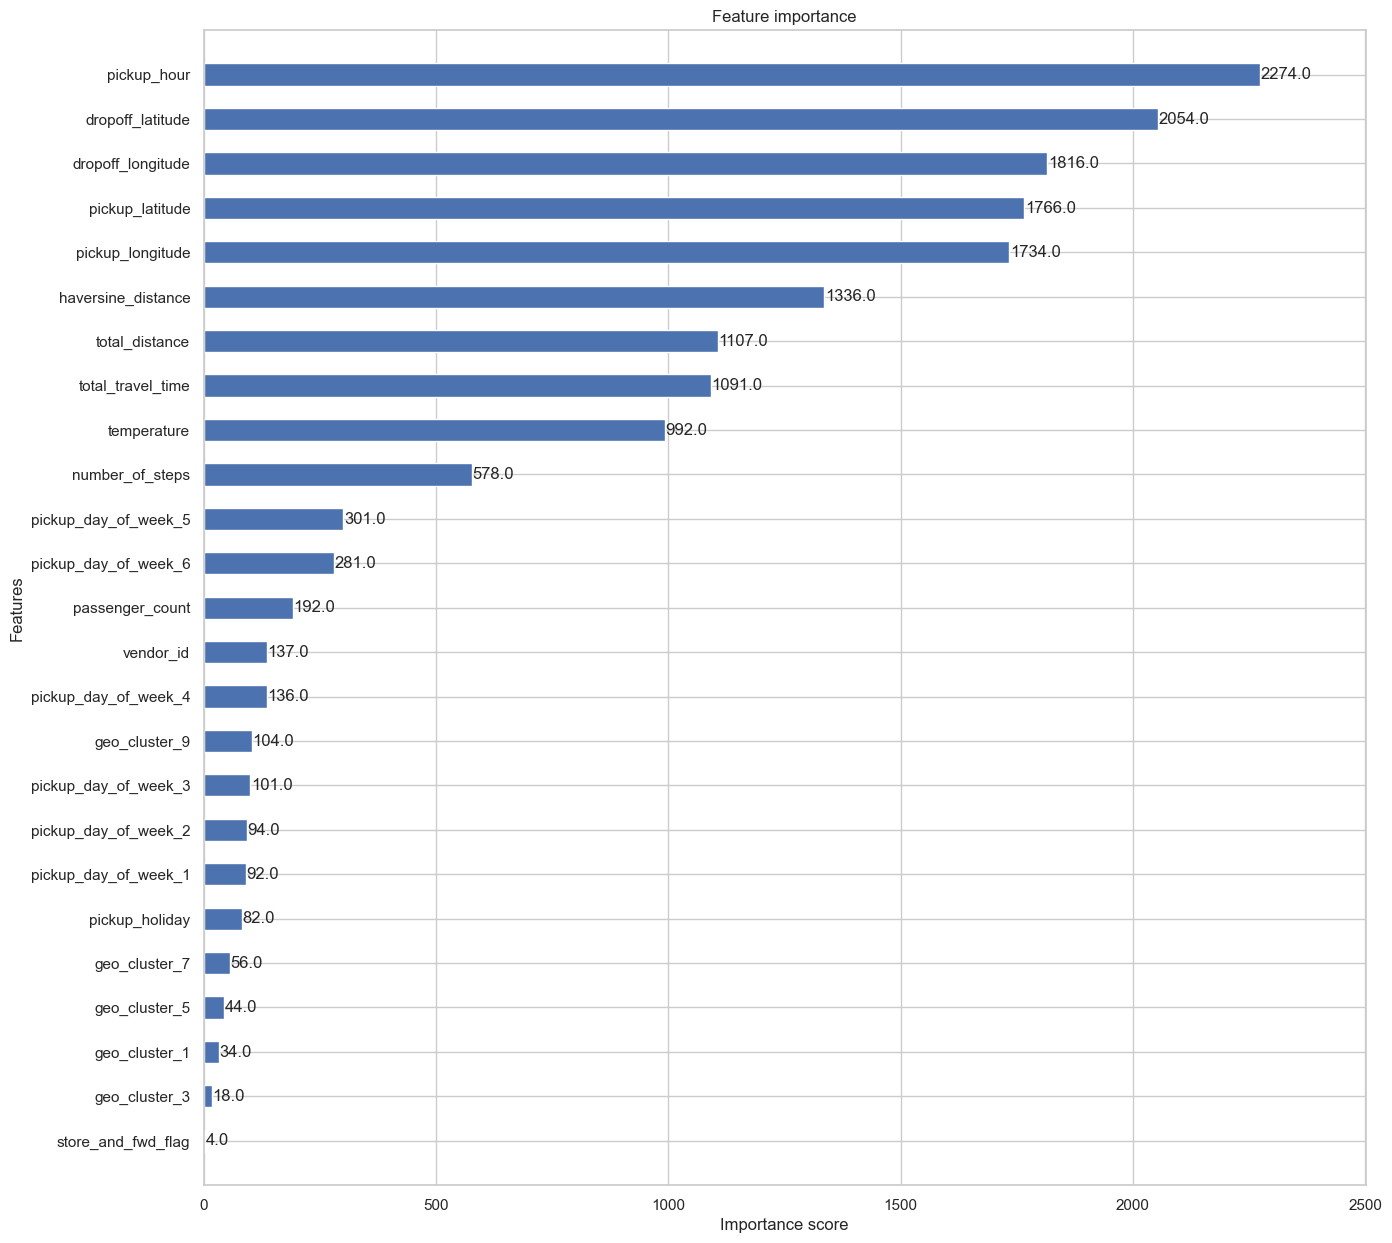

In [671]:
fig, ax = plt.subplots(figsize = (15,15))
xgb.plot_importance(model, ax = ax, height=0.5)